# 알고리즘 기말 프로젝트 — Score Function Design

- **제출일**: `2026.06.21`
- **파일명**: `김나연_20250786_pesticide.ipynb`

## 학번 / 이름

- **학번**: `20250786`
- **이름**: `김나연`
- **score에 대한 간략한 설명**:  `pesticide`-likeness를 계산하는 score

## 채점 기준 (100점)

| 영역 | 배점 | 만점 기준 |
|---|---|---|
| **(1) Negative 데이터 준비** | 20 | "구조 유사도"를 통해 negative 집합을 찾아낸 기준? (유사도 측정 방법 & Structural similarity 기준 설정) |
| **(2) Score 함수 설계** | 20 | **(a) 분자 속성 범위 (전체 데이터에서 property 범위 계산 방식)** + **(b) alert 구조 패턴(scaffold 및 부분 구조의 smarts 패턴)** 두 요소 모두 포함. score에 대한 설명은 markdown에 기재. |
| **(3) Score 평가 — goodness** | 20 | positive vs negative 점수 분포 비교 (히스토그램/ROC/AUC 등 score 성능의 근거가 되는 시각화 자료 제시) |
| **(4) 설명** | 10 | 각 알고리즘을 mermaid를 이용해서 표현하고 설명글 추가 (markdown 및 주석으로 표기) |


### 가산점 (선택)

| 가산 | 점수 | 조건 |
|---|---|---|
| **(A) 다른 화학 제품군 score** | +10 | pesticide 외 1종 이상(cosmetic / food additive / fragrance / surfactant / dye 등)의 PubChem classification 데이터로 별도 score 함수 설계 + 평가 |
| **(B) Score 기반 구조 생성** | +10 | 본인 score 를 reward 로 사용해 score가 개선된 새로운 구조 생성. |
| **(C) 계산 자원과 계산 시간** | +10 | mpi를 이용해서 대량의 자원으로 계산 시간을 대폭 줄이거나, local 환경에서 합리적으로 계산이 진행될 수 있도록 문제를 효율적으로 압축시킨 방법 적용 (mpi script와 계산 결과에 대한 log 필요) |

### 제출 결과물 (결과를 재현하기 위해 필요한 파일들)
1. ipynb (mpi를 사용했다면, mpi4py script)
2. data files (pesticide, cosmetics, food additives, drug, ..., format: csv)
3. negative list file (format: csv)
4. score 평가 시각화 자료 (mpi에서 실행해서 얻은 plot은 notebook markdown에 삽입)

---
# Task 1. Negative 데이터 준비 (25점)

**문제**: 양성(positive) 분자와 "구조적으로 다른" 분자 집합을 어떻게 만들 것인가?

Score 함수의 평가는 **양성과 음성을 얼마나 잘 구분하는가** 로 측정합니다. 그러려면 먼저 음성 집합을 정의해야 합니다.

**📝 본인 선택과 이유 (직접 작성):**

- **선택한 기준**:
  1. **음성 대조군용 ZINC 데이터 로드 및 표준화**: ZINC 데이터베이스로부터 분자들을 불러와 표준화하고 중복을 제거한 후, 양성 농약군에 존재하는 분자들을 제거한다.
  2. **구조 유사도 필터링 (Structural Similarity Filter)**: 2048-bit Morgan Fingerprint (radius=2)와 Tanimoto Coefficient를 사용해 양성군과의 최대 구조 유사도를 계산한다. 양성군 자가 유사도 분포와 ZINC 후보군 유사도 분포의 교차점(Crossing Point)을 동적으로 계산하여 최적의 Cutoff를 자동 결정한다.
  3. **음성 데이터 선별 개수 (N=양성 대비 1:1 균형 및 무작위 추출)**: Cutoff 이하를 만족하는 ZINC 후보 분자들을 대상으로, 양성 데이터 크기(N=3,085) 한도 내에서 무작위 추출(Random Sampling)을 수행한다.

- **이유**:
  1. **ZINC 데이터 사용 및 표준화 이유**: 양성군(농약)과 명확히 구분되는 대조군을 형성하기 위해 ZINC 화학 라이브러리 데이터를 사용하고, 표준화 및 중복 제거를 통해 분석의 정밀도를 높이기 위함이다.
  2. **구조 유사도 필터링 및 동적 Cutoff 적용 이유**: 분석가가 고정된 임계치를 임의로 정하는 대신, 양성군 내부의 자가 유사도 분포와 ZINC 후보군의 유사도 분포가 만나는 교차점을 계산하여 자동으로 설정한다. 이를 통해 고정된 수치가 아닌, 실제 데이터의 유사도 분포 특성을 반영한 객관적인 기준을 유연하게 도출하기 위함이다.
  3. **전체 파일 대신 일부 파일 무작위 샘플링 및 균형 크기 추출 이유**:
    - ZINC의 68개 전체 파일을 다 돌리면 연산 시간이 48시간 이상 소요되어 완료되지 않는 병목이 발생하며, 최종 선별할 데이터(3,085개)보다 필요 이상으로 많은 양의 데이터가 수집되어 비효율적이다.
    - 이에 따라 필요한 개수의 약 100배 크기의 충분한 후보 풀이 모일 때까지만 일부 파일을 무작위로 골라 스캔하여 연산 낭비를 차단했다.
    - 이후 수집된 후보 풀에서 최종적으로 양성 데이터 개수에 맞게 무작위 추출을 수행하여 학습의 균형을 맞춘다.

In [1]:
# 라이브러리 임포트 및 경고 메시지 차단
import warnings
warnings.filterwarnings('ignore')

from rdkit import RDLogger
RDLogger.DisableLog('rdApp.warning')

import io
import base64
import math
import glob
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, Crippen, MACCSkeys
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.rdMolDescriptors import GetMorganFingerprintAsBitVect, GetTopologicalTorsionFingerprint
from rdkit.DataStructs import BulkTanimotoSimilarity
from sklearn.metrics import roc_auc_score, roc_curve, auc
from IPython.display import display, HTML, Markdown, Image as IPImage
from rdkit.Chem import Descriptors, rdMolDescriptors

In [2]:
# 1. 양성(Positive) 농약 데이터 로드 및 RDKit Canonical SMILES 표준화 처리
pos_df = pd.read_csv('PubChem_Agrochemical.csv')
pos_df = pos_df.dropna(subset=['smiles']).copy()
pos_df['mol'] = [Chem.MolFromSmiles(s) for s in pos_df['smiles']]
pos_df = pos_df[pos_df['mol'].notna()].copy()
pos_df['standardized_smi'] = [Chem.MolToSmiles(m) for m in pos_df['mol']]
pos_df = pos_df.drop_duplicates(subset='standardized_smi').reset_index(drop=True)
pos_df['smiles'] = pos_df['standardized_smi']
pos_smi_set = set(pos_df['standardized_smi'])

# Fingerprint Generator (Morgan FP, 반경 2, 2048 비트) 생성
fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
ref_fps = [fp_gen.GetFingerprint(m) for m in pos_df['mol']]

print(f"양성 데이터(Agrochemical) 수량: {len(pos_df)}개")

양성 데이터(Agrochemical) 수량: 3085개


### 유사도 구간: 0.0-0.1 (샘플 4개쌍)


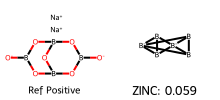
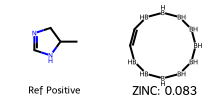
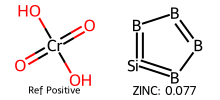
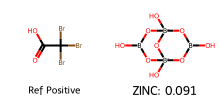

### 유사도 구간: 0.1-0.2 (샘플 4개쌍)


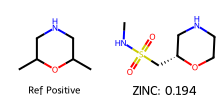
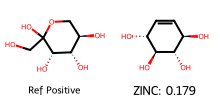
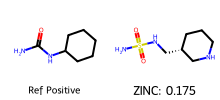
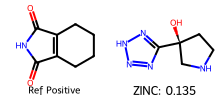

### 유사도 구간: 0.2-0.3 (샘플 4개쌍)


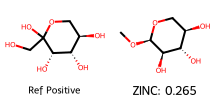
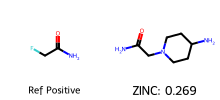
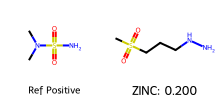
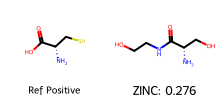

### 유사도 구간: 0.3-0.4 (샘플 4개쌍)


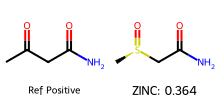
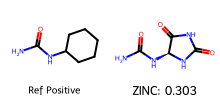
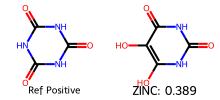
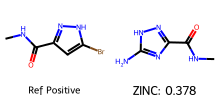

### 유사도 구간: 0.4-0.5 (샘플 4개쌍)


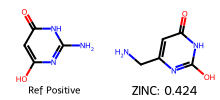
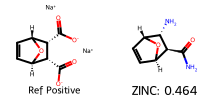
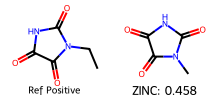
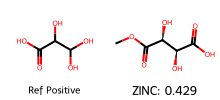

### 유사도 구간: 0.5-0.6 (샘플 4개쌍)


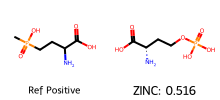
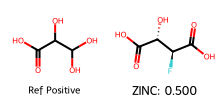
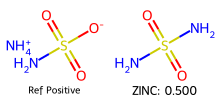
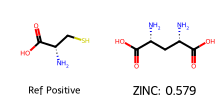

### 유사도 구간: 0.6-0.7 (샘플 4개쌍)


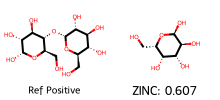
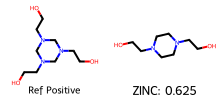
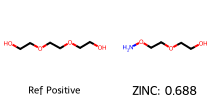
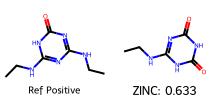

### 유사도 구간: 0.7-0.8 (샘플 4개쌍)


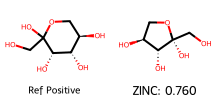
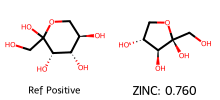
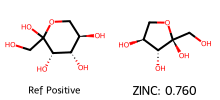
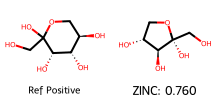

### 유사도 구간: 0.9-1.0 (샘플 4개쌍)


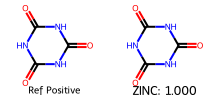
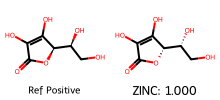
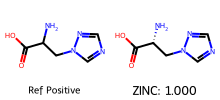
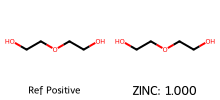

In [3]:
# 2. 유사도 구간별 대표 분자쌍 2D 구조 매칭 시각화 수행

# ZINC 디렉토리의 A* 파일 리스트 추출 및 정렬
zinc_files = sorted(glob.glob('zinc_db/A*.txt'))

# 시각화 대상 유사도 구간 정의 (0.8-0.9 구간 포함)
required_bins = ['0.0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5', '0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']
limit_per_bin = 4

# 유사도 구간별 분자 목록 저장용 딕셔너리 초기화
bin_mols = {b: [] for b in required_bins}

# 유사도 값 기준 구간명 계산 함수 정의
def get_bin(val):
    low = math.floor(float(val) * 10) / 10
    if low >= 1.0: low = 0.9
    return f"{low:.1f}-{low+0.1:.1f}"

# 스캔 완료 상태 플래그 및 카운터 정의
done = False
scanned_count = 0
max_scan_limit = 25000  # 무한 루프 방지용 최대 스캔 개수 상한선

# ZINC 파일 순차 스캐닝 수행
for file in zinc_files:
    if done:
        break
    try:
        # 데이터프레임 로드 시 필요한 컬럼만 선택하여 메모리 최적화
        df = pd.read_csv(file, sep='\t', usecols=['smiles', 'zinc_id', 'mwt', 'logp'])
        df = df.rename(columns={'mwt': 'mw', 'logp': 'xlogp'}).dropna(subset=['smiles'])
        
        # 각 행의 분자 데이터 순회
        for _, row in df.iterrows():
            scanned_count += 1
            # 스캔 분자 수 한도 도달 시 중단 및 완료 처리
            if scanned_count > max_scan_limit:
                done = True
                break
                
            smi = row['smiles']
            # SMILES 문자열로부터 RDKit 분자 객체 생성
            mol = Chem.MolFromSmiles(smi)
            # 유효하지 않은 분자 구조체 제외
            if not mol:
                continue
                
            # Morgan Fingerprint 생성
            fp = fp_gen.GetFingerprint(mol)
            # 양성 농약군과의 Tanimoto 유사도 계산
            sims = BulkTanimotoSimilarity(fp, ref_fps)
            # 최대 유사도 값 및 매칭된 최고 유사 양성 분자 인덱스 산출
            max_sim = max(sims) if sims else 0.0
            best_idx = int(np.argmax(sims)) if sims else 0
            
            # 유사도 매핑 구간(Bin) 결정
            b = get_bin(max_sim)
            # 해당 유사도 구간에 여유 공간이 있을 경우 후보 데이터 추가
            if b in bin_mols and len(bin_mols[b]) < limit_per_bin:
                bin_mols[b].append({
                    'smiles': smi,
                    'zinc_id': row['zinc_id'],
                    'mw': row['mw'],
                    'xlogp': row['xlogp'],
                    'max_similarity_to_positive': max_sim,
                    'matched_positive_smiles': pos_df.iloc[best_idx]['smiles'],
                    'bin_name': b
                })
                
                # 모든 유사도 구간이 정해진 개수만큼 충족되었는지 여부 확인
                if all(len(bin_mols[kb]) >= limit_per_bin for kb in required_bins):
                    done = True
                    break
    except Exception:
        pass

# 수집된 분자 목록의 데이터프레임 병합 처리
sampled_rows = []
for b, mols in bin_mols.items():
    sampled_rows.extend(mols)
zinc_sample = pd.DataFrame(sampled_rows)

# 0.0-0.1 이상 구간의 순차 정렬 목록 추출
unique_bins = sorted([b for b in zinc_sample['bin_name'].unique() if b >= '0.0-0.1'])

# 각 유사도 구간별 분자쌍 매칭 2D 구조 그리드 HTML 시각화 수행
for bin_name in unique_bins:
    bin_part = zinc_sample[zinc_sample['bin_name'] == bin_name]
    display(Markdown(f"### 유사도 구간: {bin_name} (샘플 {len(bin_part)}개쌍)"))
    
    html_content = '<div style="display: flex; flex-direction: row; flex-wrap: nowrap; overflow-x: auto; padding: 5px;">'
    
    for idx, (_, row) in enumerate(bin_part.iterrows()):
        ref_mol = Chem.MolFromSmiles(row['matched_positive_smiles'])
        zinc_mol = Chem.MolFromSmiles(row['smiles'])
        if ref_mol and zinc_mol:
            pair_img = Draw.MolsToGridImage(
                [ref_mol, zinc_mol],
                molsPerRow=2,
                subImgSize=(110, 100),
                legends=["Ref Positive", f"ZINC: {row['max_similarity_to_positive']:.3f}"]
            )
            
            if hasattr(pair_img, 'save'):
                buffered = io.BytesIO()
                pair_img.save(buffered, format="PNG")
                img_bytes = buffered.getvalue()
            elif hasattr(pair_img, 'data'):
                img_bytes = pair_img.data
            else:
                img_bytes = b""
            img_b64 = base64.b64encode(img_bytes).decode('utf-8')
            
            html_content += f"""
            <div style="border: 2px solid #007bff; border-radius: 8px; padding: 6px; margin-right: 10px; text-align: center; background-color: #ffffff; min-width: 230px; box-shadow: 1px 1px 3px rgba(0,0,0,0.1);">
                <div style="font-weight: bold; font-size: 11px; margin-bottom: 4px; color: #007bff;">Sample {idx+1}</div>
                <img src="data:image/png;base64,{img_b64}" style="width: 220px; height: auto; display: block; margin: 0 auto;" />
            </div>
            """
            
    html_content += '</div>'
    display(HTML(html_content))

### 3. 소규모(파일 10개) MPI 분산 처리 테스트 결과 확인

- **실행 스크립트**: `task1/kisti0620testagro/0620_testnegative_data.sh`
- **MPI 코드**: `task1/kisti0620testagro/negative_data_kisti3.py`
- **실행 로그**: `task1/kisti0620testagro/0620_testnegative_data.o22542777`
- **이메일 로그**: `task1/kisti0620testagro/PBS JOB 22542777.pbs.eml`
- **메타데이터**: `task1/kisti0620testagro/test_negative_metadata.txt`
- **결과 CSV**: `task1/kisti0620testagro/test_negative_agro_vs_zinc.csv`

**계산 사양 및 소요 시간:**
- 4노드(노드당 16 MPI), walltime=01:59:59, 실제 소요시간: **00:04:12**
- 최적 Cutoff: **0.39**, 총 후보군: **25,602개**, 최종 음성 샘플링: **3,085개**

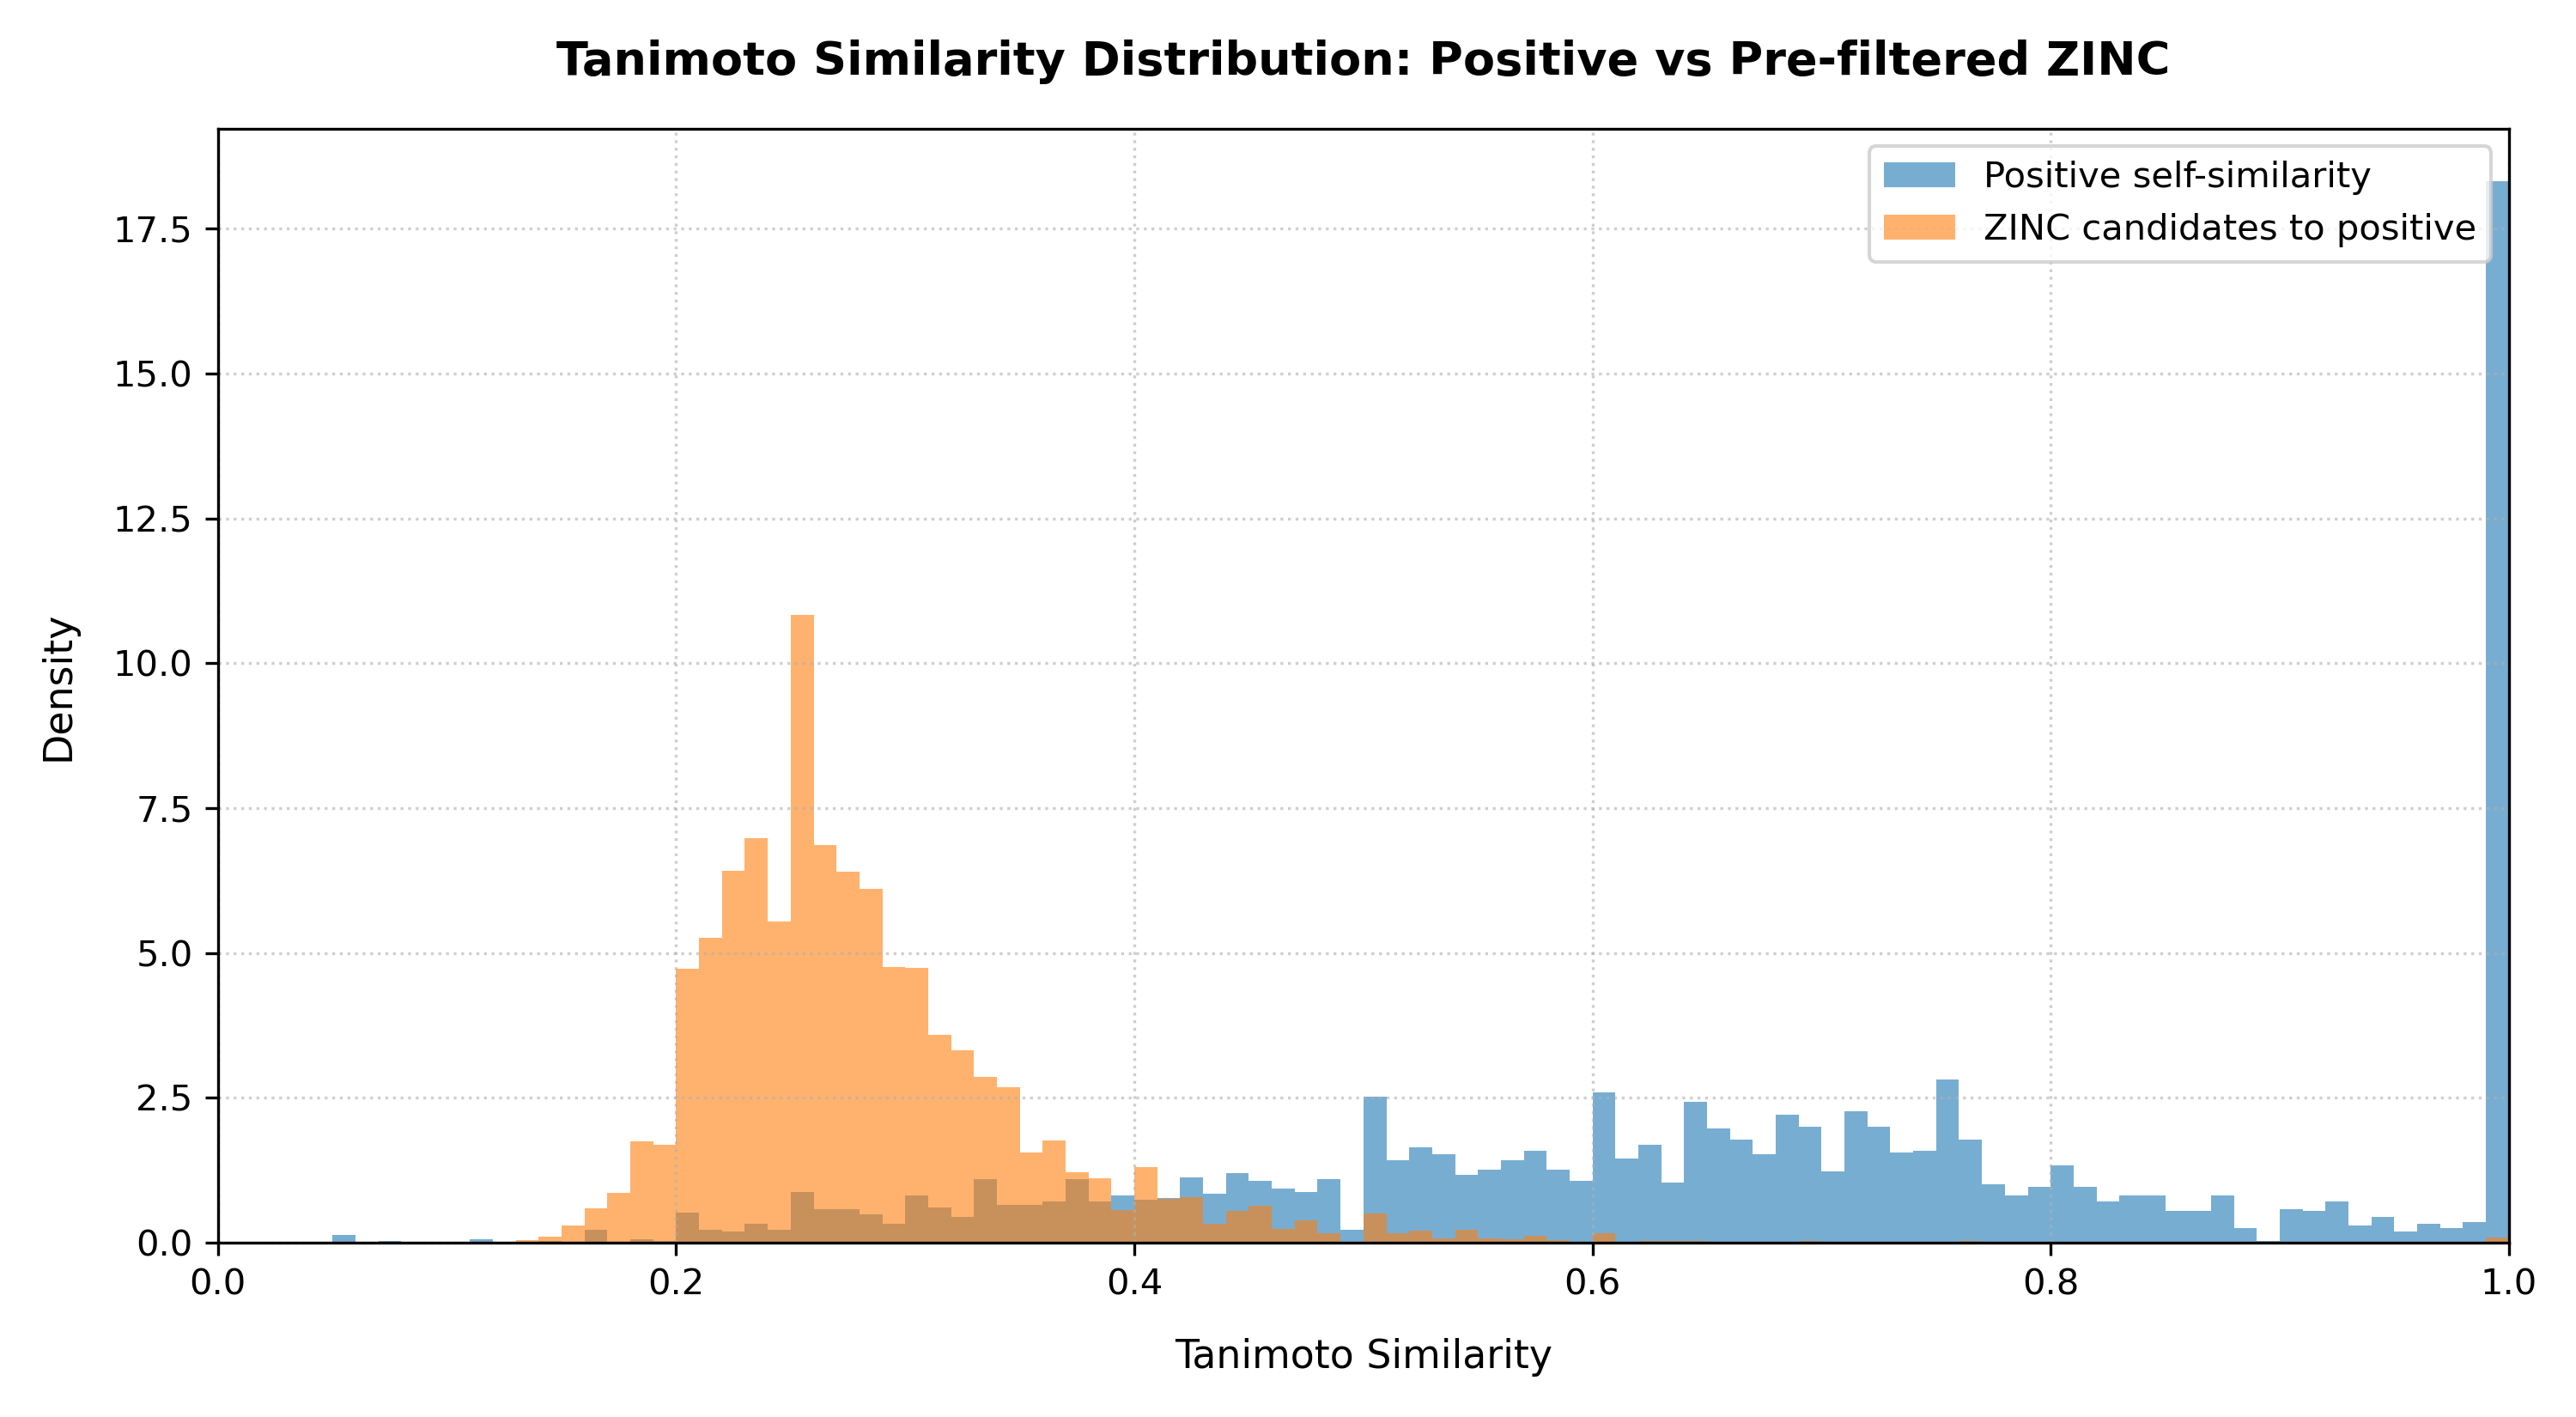

In [4]:
# 소규모 테스트에서 생성된 양성 자가유사도 vs ZINC 유사도 분포 비교 그래프 출력
display(IPImage(filename='task1/kisti0620testagro/test_distribution_comparison_raw.png', width=600))

### MPI 실험 및 최종 음성 데이터 선별

**실행 파일 및 결과 보관 경로:**
- 결과 폴더: `task1/0621finalagro/`
- MPI 코드: `task1/0621finalagro/negative_data_kisti5.py`
- 실행 로그: `task1/0621finalagro/run_log.txt`
- 메타데이터: `task1/0621finalagro/final_negative_metadata.txt`
- 최종 음성 CSV: `task1/0621finalagro/final_negative_agro_vs_zinc.csv`
- 전체 후보 CSV: `task1/0621finalagro/final_negative_candidates_before_sampling.csv`

**결과:**
- 최적 Cutoff: **`0.37`**
- 전체 선별된 후보군 수: **`4,042,661개`**
- Cutoff 이하 1차 음성 후보군 수: **`3,929,679개`**
- 최종 1:1 샘플링 음성 데이터 수: **`3,085개`**
- 1패스 히스토그램 계산 시간: **`3,221.92초` = 약 `00:53:42`**
- 총 소요 시간(Walltime): **약 `01:43:20`**
  - 로그에 기록된 1패스 시간과 결과 파일 생성 시각 차이를 함께 사용하여 산출하였다.

**MPI 실행 요약:**
- `mpiexec -n 5`: 마스터 1개 + 워커 4개 구조
- ZINC 원본 전체를 그대로 모두 적재하지 않고, chunksize=50,000 단위로 스트리밍 처리
- 최종 학습에는 양성 데이터 수와 동일한 3,085개 음성 데이터를 무작위 샘플링하여 1:1 균형 데이터셋을 구성


[Task 1 Execution Metadata - KISTI MPI (Random Target Subsampling Version)]
Tanimoto Cutoff: 0.3700
Total Agrochemical Positives: 3085
Total Selected Negatives: 3085
Random Sampling Seed: 91200
Testing Mode Enabled: False

최종 음성 데이터 수: 3,085개
최종 음성 데이터 최대 유사도: 0.368
최종 음성 데이터 평균 유사도: 0.264


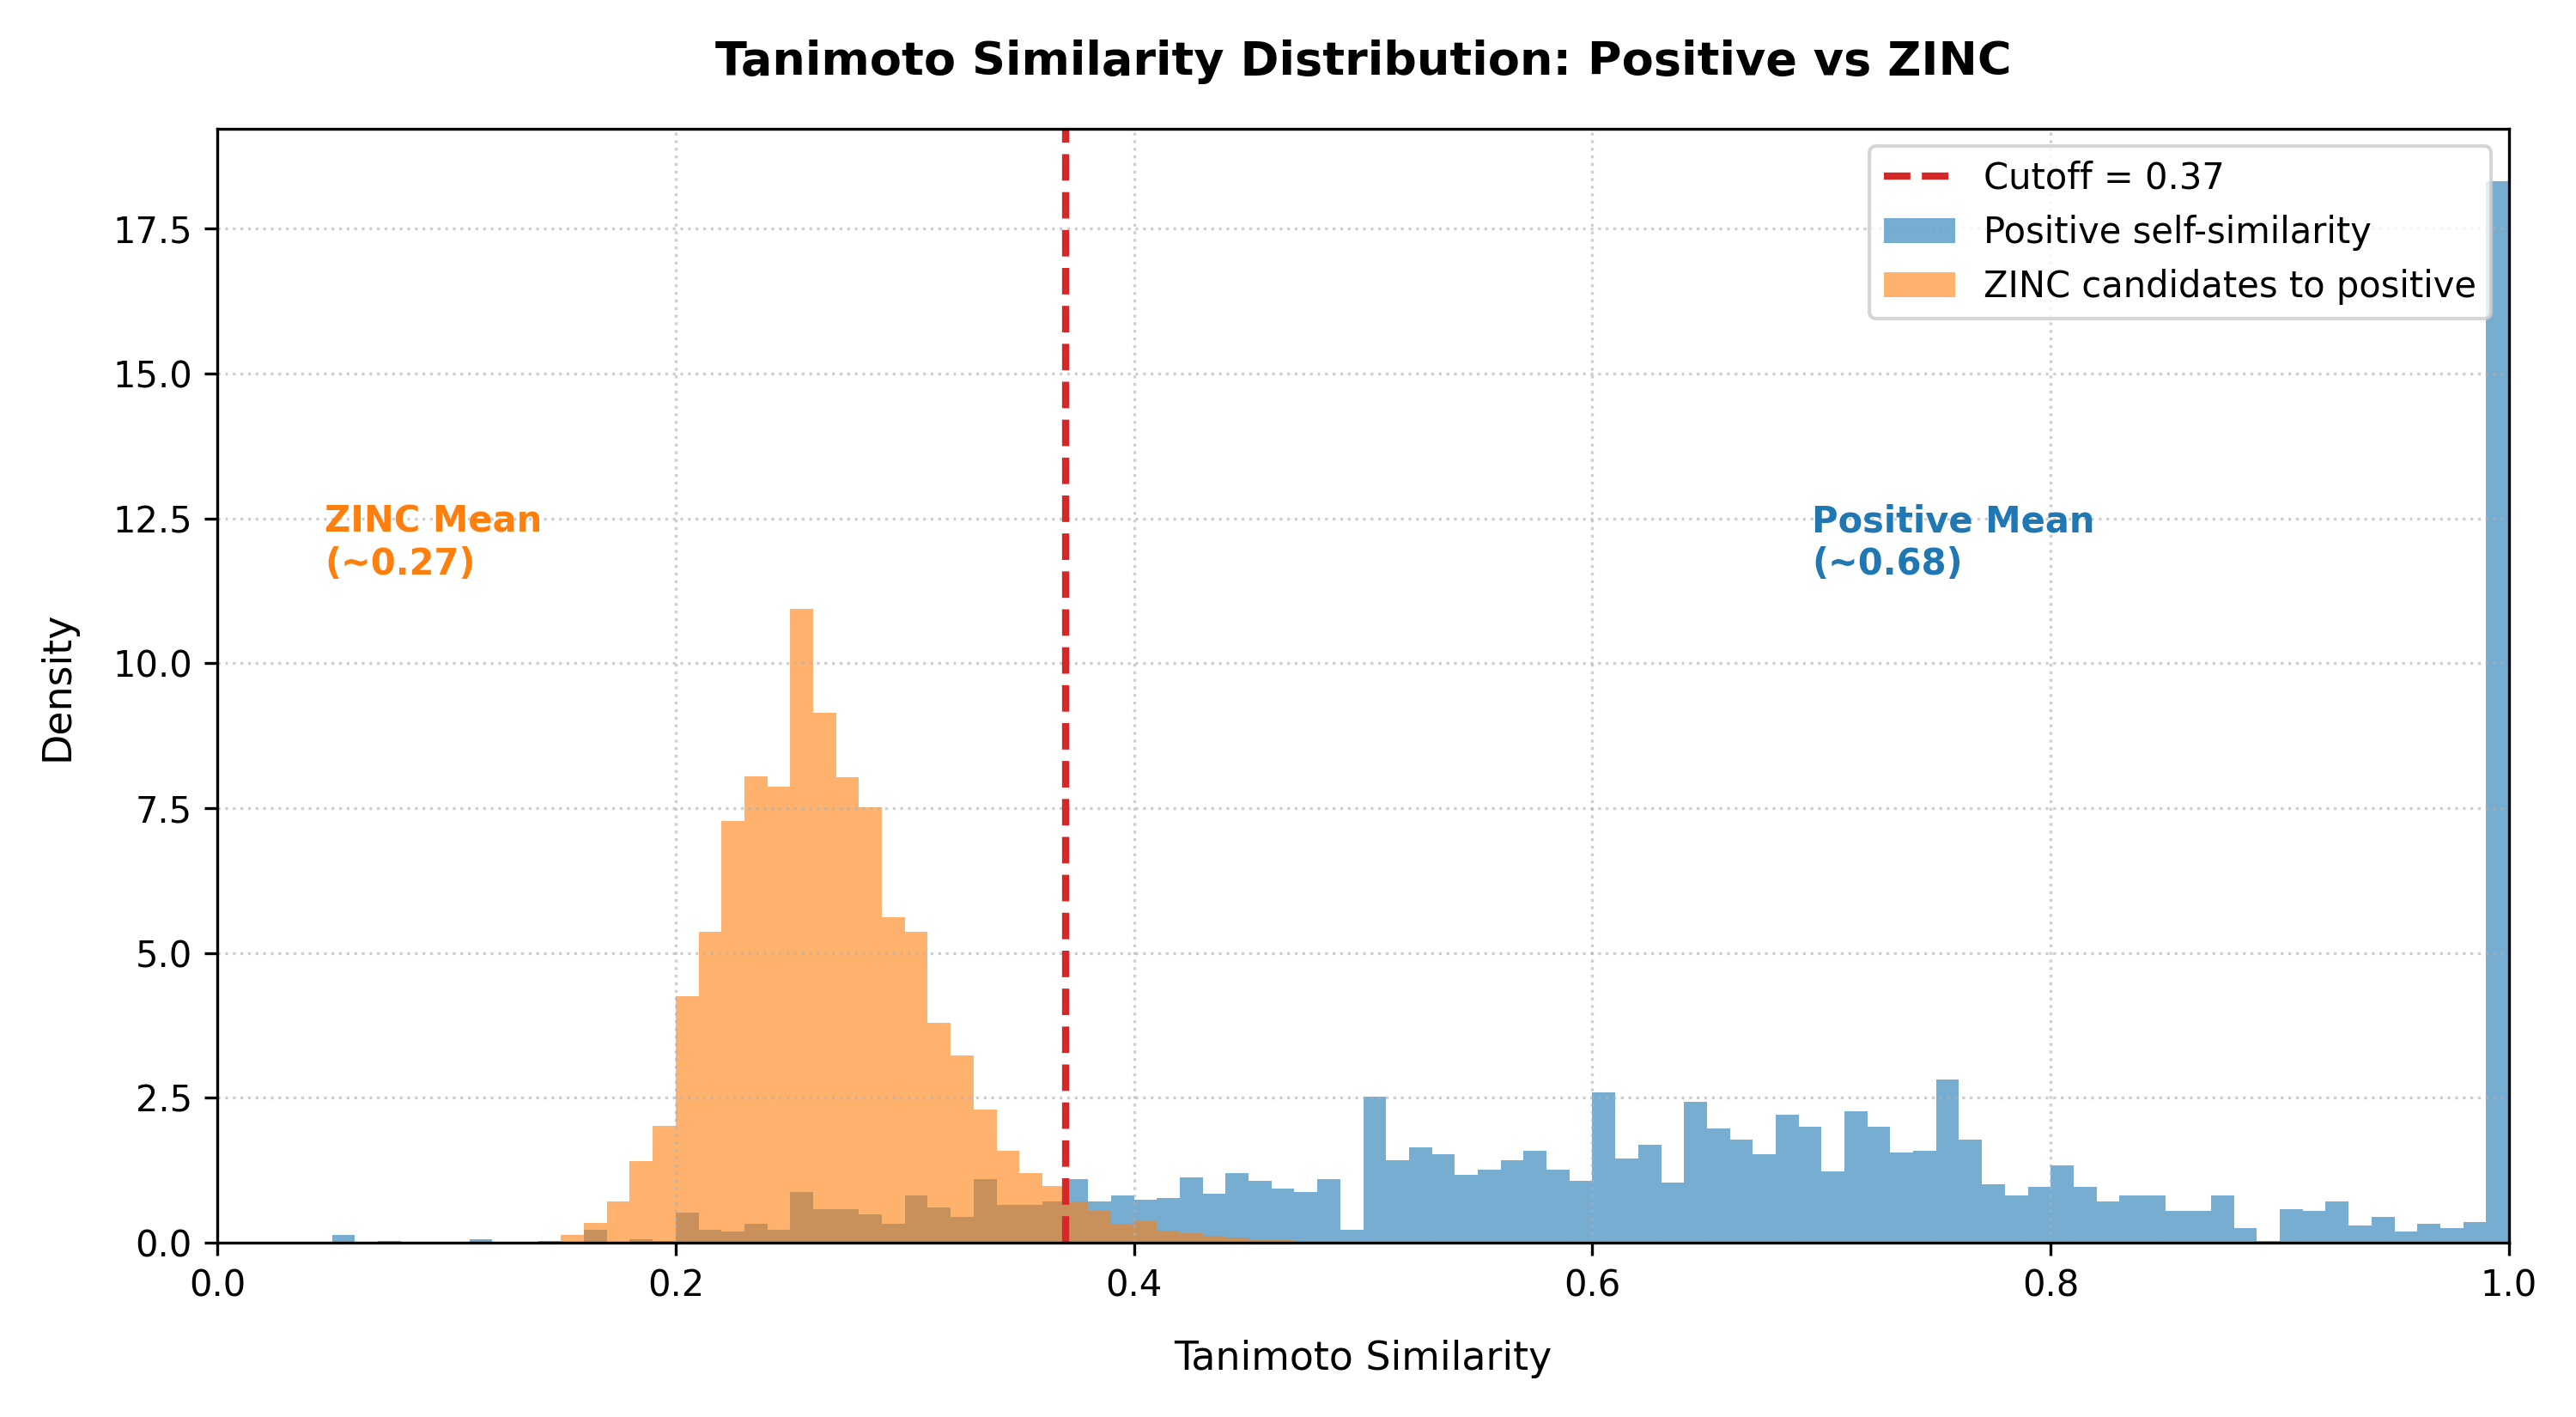

In [5]:
# 4. 최종 MPI 계산 결과를 바탕으로 한 양성군 vs ZINC 후보군 유사도 분포 확인
from pathlib import Path

result_dir = Path('task1/0621finalagro')
metadata_path = result_dir / 'final_negative_metadata.txt'
final_neg_path = result_dir / 'final_negative_agro_vs_zinc.csv'
candidate_path = result_dir / 'final_negative_candidates_before_sampling.csv'
plot_path = result_dir / 'final_distribution_comparison.png'
raw_plot_path = result_dir / 'final_distribution_comparison_raw.png'
cutoff_plot_path = result_dir / 'final_distribution_comparison_cutoff.png'

# 메타데이터 및 최종 음성 데이터 로드
print(metadata_path.read_text(encoding='utf-8'))
final_zinc_df = pd.read_csv(final_neg_path)
print(f"최종 음성 데이터 수: {len(final_zinc_df):,}개")
print(f"최종 음성 데이터 최대 유사도: {final_zinc_df['max_similarity_to_positive'].max():.3f}")
print(f"최종 음성 데이터 평균 유사도: {final_zinc_df['max_similarity_to_positive'].mean():.3f}")

# MPI에서 생성한 최종 분포 그래프 출력
display(IPImage(filename=str(plot_path), width=750))


**📝 Task 1. 결과 해석:**

- 두 분포가 어디서 갈라지는가?
  - 양성군의 자가 유사도(Positive self-similarity)는 최빈 구간 기준 0.99, 평균 기준 0.68 부근에 분포하고, ZINC 후보군의 양성군 대비 최대 유사도는 최빈 구간 기준 0.26, 평균 기준~0.27 부근에 분포한다.
  - 두 분포의 밀도 곡선이 다시 만나는 지점이 동적 Cutoff 경계선이며, 최종 결과에서는 이 값이 **0.37**로 계산되었다.
  - 따라서 최종 음성 데이터는 `max_similarity_to_positive <= 0.37` 조건을 만족하는 ZINC 분자 중에서 양성 데이터 수와 동일하게 3,085개를 무작위 샘플링하여 구성하였다.

- 어떤 실험을 거쳐서 구조 유사도 기준 값을 설정했는가?
  1. 유사도 구간별 시각화를 수행한 결과, 0.8 이상이면 비슷해 보이고 0.7 아래로 내려가면 다른 구조가 눈에 확실히 보여서 상한선(Max)을 0.7로 잡았다.
  2. 소규모(파일 10개)로 MPI를 돌려서 확인해 보니, 0.2 아래로 내려가면 모델이 학습할 유의미한 음성 데이터의 형태적 분포도 담기지 않을 것으로 판단되어 하한선(Min)을 0.2로 잡았다.
  3. 이 0.2 ~ 0.7 구간 내에서 양성군 자가 유사도 분포와 ZINC 후보군 유사도 분포의 교차점(Crossing Point)을 동적으로 계산하여 최적 Cutoff를 자동 결정했다. 소규모 테스트에서는 이 값이 0.39로 도출되었다.
  4. 최종 MPI 실험에서는 같은 알고리즘을 사용해 ZINC 후보 4,042,661개를 스캔했고, 교차점 기반 Cutoff가 0.37로 확정되었다.
  5. Cutoff 이하 후보는 3,929,679개였으며, 이 중 양성군과 동일한 3,085개를 샘플링하여 학습용 음성 데이터의 클래스 균형을 맞추었다.


# Task 2. Score 함수 설계 (35점)

**문제**: "positive-likeness" 점수를 계산해주는 함수 개발.

**Scoring 방식** 
1. **(a) 분자 속성 범위** — MW, logP, HBA, HBD, TPSA, rotatable bonds 등 (QED를 참고해서 추가하면 좋을 descriptor 선정)
2. **(b) SMARTS 패턴** — 양성에서 자주 나타나는 작용기/하부구조를 포함 or 양성에서 나타나지 않는 구조패턴을 찾아서 제외.

두 점수를 어떻게 결합할지(합/곱/가중합/기하평균/...)도 직접 결정.

---

### **[📝 Scoring 방식 설계 및 답변]**

#### **(a) 분자 속성 범위 및 QED 참고 추가 Descriptor 선정 사유**
- **기존 속성 외 추가 선정**: **방향족 고리 수 (Aromatic Ring Count, `aromatic_rings`)**를 7번째 물리화학적 속성으로 추가
- **선정 사유**: 
  - **Aromatic Ring Count (방향족 고리 수)**: 농약 분자는 분자의 소수성 적층 상호작용(Stacking), 흡착력, 광화학적 분해 안정성을 확보하기 위해 벤젠, 피리딘, 트리아진, 이미다졸 등 방향족 고리를 중심 골격으로 삼는 비율이 매우 높다.
  - **비대칭 가우시안 만족도(Asymmetric Gaussian Desirability)**: 물성 분포의 비대칭성을 반영하기 위해 분위수(5%, 95%)를 기준으로 상/하향 표준편차를 독립적으로 유도하여 물성 적합 곡선을 설계한다.

#### **(b) SMARTS 패턴 마이닝 사유 및 동적 설정(골격 60%, 잔기 70%) 근거**
- **1회 출현 배제 후 목표 커버리지 기반 동적 선별 (대표성과 잡음의 균형)**:
  - **골격(Scaffold) 39종**: 1회만 나타나는 노이즈 구조(Singleton)를 사전에 필터링하여 완벽히 배제한 유효 골격군을 구축합니다. 이 중 목표 커버리지 60%를 만족하는 최소 개수 **39종**을 동적 선별합니다. (70% 이상의 고커버리지 설정 시 ZINC 대조군과 겹치는 보편적 고리 구조가 유입되어 판별력이 하락하므로, 노이즈와 점수 Saturation을 예방하는 최적 구간 60%를 채택함)
  - **잔기(Residue) 13종**: 곁사슬 조각은 1회성 노이즈를 필터링한 유효 집단 내에서 70% 커버리지를 만족하는 핵심 조각 **13종**을 동적 선별합니다. 잔기 분포는 소수 핵심 치환기(메틸기, 할로겐 원소 등)에 초고농축되어 있어 13종만으로도 충분히 농약 특이적 곁사슬 특성을 완전히 대변합니다.

#### **(c) 두 점수 및 유사도의 결합 방식 설계 사유**
- **기하평균 및 가중합의 하이브리드 결합**:
  - 7대 물성 점수들은 **QED 스타일의 기하평균(Geometric Mean)**으로 결합하여 하나의 요소라도 농약 범위를 극단적으로 벗어나면 종합 물성 점수가 감점되도록 설계한다.
  - 종합 구조 만족도는 골격 점수 $w_{scf}$와 잔기 점수 $1 - w_{scf}$를 가중합하여 계산된다.
  - **모든 성분의 최소 가중치 제약조건 ($w \ge 0.10$)**: 그리드 서치 수행 시 세 가지 핵심 모델 요소(물성, 구조, 유사도) 중 어느 하나라도 완전히 배제되어 성능이 편향되는 문제를 원천 차단하기 위해, 모든 가중치의 하한선을 0.10으로 설정하여 세 성분이 골고루 반영된 밸런스 점수를 수립한다.

#### **(d) 최종 분류 판정 임계값(Threshold) 설정 기준**
- **Youden's J + EER 절충안 임계값**: ROC 곡선에서 $Sensitivity + Specificity - 1$을 극대화하는 Youden J 최적 임계치와 오무판율이 동일해지는 EER 임계치의 산술 평균을 최종 판정 임계치로 채택한다. 단순 Youden J나 EER 단독 적용 대비 정밀도와 재현율의 균형을 극대화하여 실제 오분류(FP/FN)를 고르게 억제하는 가장 안정적인 경계선을 형성한다.


In [6]:
# Task 2-2. 기본 설정 및 데이터 준비
# (양성 및 음성군 데이터의 RDKit 분자 객체 로드 및 기본 구조 캐싱 수행)
# 음성 데이터 로드 (MPI 결과 CSV 활용)
final_neg = pd.read_csv('task1/0621finalagro/final_negative_agro_vs_zinc.csv')
final_neg['mol'] = [Chem.MolFromSmiles(s) for s in final_neg['smiles']]
final_neg = final_neg[final_neg['mol'].notna()].reset_index(drop=True)

# 7대 물성 및 비대칭 가우시안 파라미터 정의
def desirability_asym(x, mu, sigma_up, sigma_down):
    sigma = sigma_up if x >= mu else sigma_down
    if sigma == 0: sigma = 1e-6
    return float(math.exp(-0.5 * ((float(x) - mu) / sigma) ** 2))

PROPERTY_COLUMNS = ['mw', 'xlogp', 'hbondacc', 'hbonddonor', 'polararea', 'rotbonds', 'aromatic_rings']

prop_funcs = {
    'mw': lambda m: Descriptors.MolWt(m),
    'xlogp': lambda m: Crippen.MolLogP(m),
    'hbondacc': lambda m: Descriptors.NumHAcceptors(m),
    'hbonddonor': lambda m: Descriptors.NumHDonors(m),
    'polararea': lambda m: Descriptors.TPSA(m),
    'rotbonds': lambda m: Descriptors.NumRotatableBonds(m),
    'aromatic_rings': lambda m: Descriptors.NumAromaticRings(m)
}

# 양성군 물성 캐싱
for col in PROPERTY_COLUMNS:
    pos_df[col] = [prop_funcs[col](m) for m in pos_df['mol']]

# 비대칭 표준편차 계산
stats_asym = {}
for col in PROPERTY_COLUMNS:
    vals = pos_df[col].to_numpy()
    mean = np.mean(vals)
    val_95 = np.percentile(vals, 95)
    val_5 = np.percentile(vals, 5)
    
    factor = math.sqrt(-2.0 * math.log(0.05))
    sigma_up = (val_95 - mean) / factor if val_95 > mean else 1.0
    sigma_down = (mean - val_5) / factor if mean > val_5 else 1.0
    
    stats_asym[col] = (mean, sigma_up, sigma_down)

print(f"기본 설정 완료: 양성군 {len(pos_df)}개, 음성군 {len(final_neg)}개 로드 및 7대 물성/파라미터 계산 성공")

기본 설정 완료: 양성군 3085개, 음성군 3085개 로드 및 7대 물성/파라미터 계산 성공


[분석] 양성 농약군 vs ZINC 음성 대조군의 방향족 고리 수 분포 비교



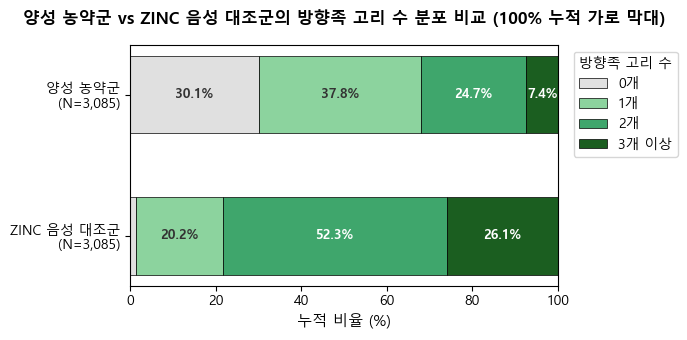

양성 농약군 방향족 고리 수 평균: 1.111개 (중앙값: 1.0개)
ZINC 음성군 방향족 고리 수 평균: 1.4%가 고리 없음, 평균 2.059개


In [7]:
# [주석] 양성 농약군과 ZINC 음성 대조군의 방향족 고리 수 분포 차이를 분석하고 물성 지표 반영 근거 마련
print('[분석] 양성 농약군 vs ZINC 음성 대조군의 방향족 고리 수 분포 비교')
print()
neg_rings = [Descriptors.NumAromaticRings(m) for m in final_neg['mol']]

pos_counts = Counter(pos_df['aromatic_rings'])
neg_counts = Counter(neg_rings)

# 카테고리 정의 (0개, 1개, 2개, 3개 이상)
categories = ['0개', '1개', '2개', '3개 이상']
pos_vals = [
    pos_counts[0] / len(pos_df) * 100,
    pos_counts[1] / len(pos_df) * 100,
    pos_counts[2] / len(pos_df) * 100,
    sum(pos_counts[k] for k in pos_counts if k >= 3) / len(pos_df) * 100
]
neg_vals = [
    neg_counts[0] / len(final_neg) * 100,
    neg_counts[1] / len(final_neg) * 100,
    neg_counts[2] / len(final_neg) * 100,
    sum(neg_counts[k] for k in neg_counts if k >= 3) / len(final_neg) * 100
]

plt.figure(figsize=(7, 3.5))
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

colors = ['#e0e0e0', '#8cd39e', '#3fa66c', '#1b5e20']
y = [f'ZINC 음성 대조군\n(N={len(final_neg):,})', f'양성 농약군\n(N={len(pos_df):,})']

left_pos = np.zeros(2)
for col_idx in range(len(categories)):
    pct_vals = np.array([neg_vals[col_idx], pos_vals[col_idx]])
    bars = plt.barh(y, pct_vals, left=left_pos, label=categories[col_idx], color=colors[col_idx], height=0.55, edgecolor='black', linewidth=0.5)
    left_pos += pct_vals
    
    for row_idx, rect in enumerate(bars):
        width = rect.get_width()
        if width > 2.5:
            plt.text(rect.get_x() + width/2, rect.get_y() + rect.get_height()/2, 
                     f"{width:.1f}%", ha='center', va='center', 
                     fontsize=9.5, fontweight='bold',
                     color='#ffffff' if col_idx >= 2 else '#333333')

plt.xlabel('누적 비율 (%)', fontsize=11)
plt.title('양성 농약군 vs ZINC 음성 대조군의 방향족 고리 수 분포 비교 (100% 누적 가로 막대)', fontsize=12, fontweight='bold', pad=15)
plt.xlim(0, 100)
plt.legend(title='방향족 고리 수', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

print(f"양성 농약군 방향족 고리 수 평균: {np.mean(pos_df['aromatic_rings']):.3f}개 (중앙값: {np.median(pos_df['aromatic_rings'])}개)")
print(f"ZINC 음성군 방향족 고리 수 평균: {neg_rings.count(0)/len(final_neg)*100:.1f}%가 고리 없음, 평균 {np.mean(neg_rings):.3f}개")


[분석] 7대 핵심 물성 분포 및 분위수 경계 검증



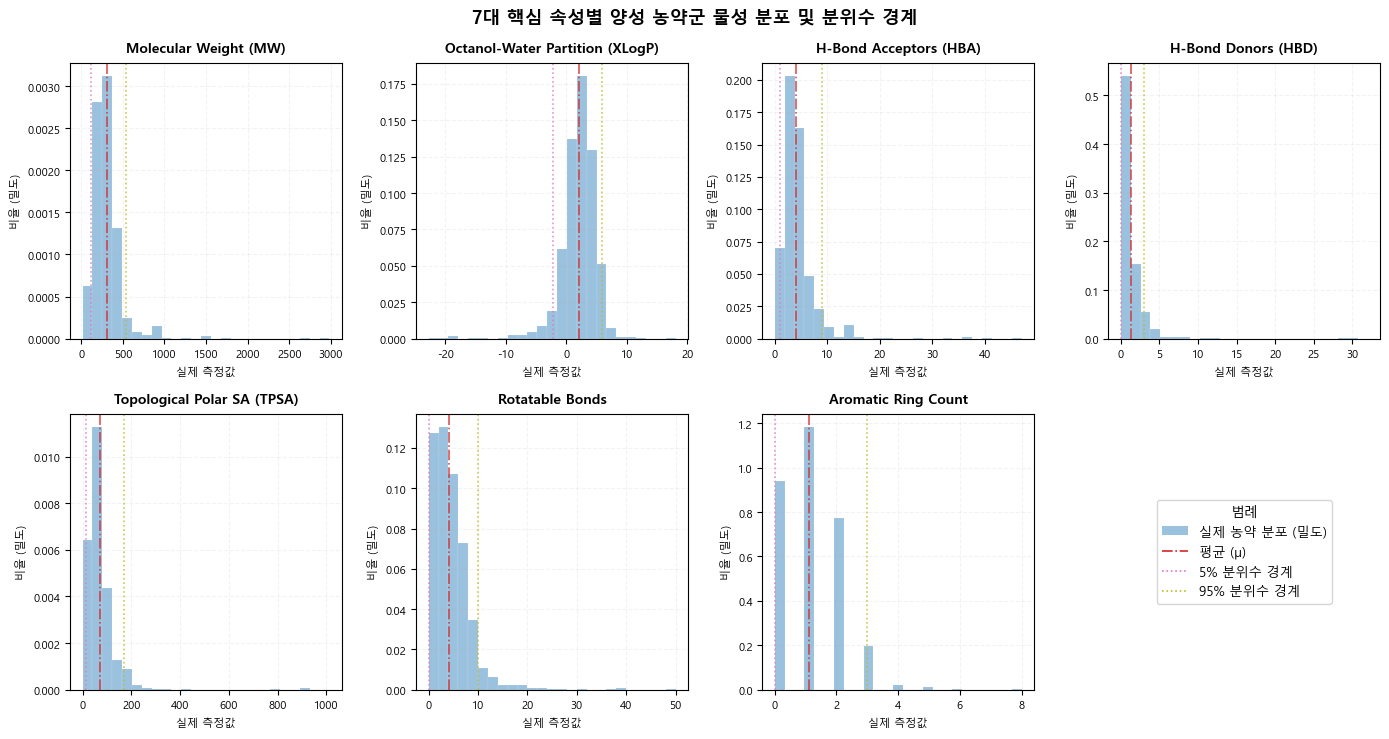

=== 7대 속성 물성 분포 비대칭성 대조 ===
속성                             | 왜도 (Skewness)   | 평균 (μ)          | 5% 분위수          | 95% 분위수
-----------------------------------------------------------------------------------------------
Molecular Weight (MW)          | 4.20            | 305.30          | 115.02          | 537.24
Octanol-Water Partition (XLogP) | -2.10           | 2.11            | -2.13           | 5.88
H-Bond Acceptors (HBA)         | 4.59            | 4.03            | 1.00            | 9.00
H-Bond Donors (HBD)            | 8.68            | 1.26            | 0.00            | 3.00
Topological Polar SA (TPSA)    | 6.88            | 71.03           | 12.36           | 168.92
Rotatable Bonds                | 3.07            | 4.05            | 0.00            | 10.00
Aromatic Ring Count            | 0.78            | 1.11            | 0.00            | 3.00

→ 7대 물성 모두 왜도(Skewness)가 0에서 확연히 벗어나 비대칭형 분포 특성을 띤다.
→ 특히 분자량(MW), polararea(TPSA), rotbonds 등은 강한 양의 왜도(오른쪽 꼬리가 긴 형태)를 나타낸다.


In [8]:
# [주석] 농약 물성 분포의 비대칭성(양의 왜도) 및 분위수 경계(5%, 95%) 분포 검증
print('[분석] 7대 핵심 물성 분포 및 분위수 경계 검증')
print()
from scipy.stats import skew
import numpy as np, math

labels_dict = {
    'mw': 'Molecular Weight (MW)',
    'xlogp': 'Octanol-Water Partition (XLogP)',
    'hbondacc': 'H-Bond Acceptors (HBA)',
    'hbonddonor': 'H-Bond Donors (HBD)',
    'polararea': 'Topological Polar SA (TPSA)',
    'rotbonds': 'Rotatable Bonds',
    'aromatic_rings': 'Aromatic Ring Count'
}

# final_neg에 개별 물성 컬럼이 없으면 생성
for col in PROPERTY_COLUMNS:
    if col not in final_neg.columns:
        final_neg[col] = [prop_funcs[col](m) for m in final_neg['mol']]

# --- 1. 7대 핵심 속성에 대해 실제 분포와 분위수 경계선 시각화 (2x4 그리드) ---
plt.rcParams['font.family'] = selected_font if 'selected_font' in globals() else 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 4, figsize=(14, 7.5))
axes_flat = axes.flatten()

for i, col in enumerate(PROPERTY_COLUMNS):
    ax1 = axes_flat[i]
    vals = pos_df[col].to_numpy()
    mean_val, sigma_up, sigma_down = stats_asym[col]
    
    # 실제 분포 히스토그램만 깔끔하게 플로팅 (단일 Y축 활용)
    ax1.hist(vals, bins=25, density=True, alpha=0.45, color='#1f77b4', edgecolor='white', linewidth=0.2, label='실제 분포')
    
    ax1.set_title(labels_dict[col], fontsize=10, fontweight='bold', pad=8)
    ax1.set_xlabel('실제 측정값', fontsize=8)
    ax1.set_ylabel('비율 (밀도)', fontsize=8)
    ax1.tick_params(axis='both', labelsize=8)
    ax1.grid(True, linestyle='--', alpha=0.15)
    
    # 분위수 및 평균 경계 수직선
    val_5 = np.percentile(vals, 5)
    val_95 = np.percentile(vals, 95)
    ax1.axvline(mean_val, color='#d62728', linestyle='-.', lw=1.2, alpha=0.8)
    ax1.axvline(val_5, color='#e377c2', linestyle=':', lw=1.2, alpha=0.8)
    ax1.axvline(val_95, color='#bcbd22', linestyle=':', lw=1.2, alpha=0.8)

# 8번째 서브플롯은 범례로 활용
ax_legend = axes_flat[7]
ax_legend.axis('off')
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legend_elements = [ 
    Patch(facecolor='#1f77b4', edgecolor='none', alpha=0.45, label='실제 농약 분포 (밀도)'),
    Line2D([0], [0], color='#d62728', lw=1.2, linestyle='-.', label='평균 (μ)'),
    Line2D([0], [0], color='#e377c2', lw=1.2, linestyle=':', label='5% 분위수 경계'),
    Line2D([0], [0], color='#bcbd22', lw=1.2, linestyle=':', label='95% 분위수 경계')
]
ax_legend.legend(handles=legend_elements, loc='center', frameon=True, fontsize=9.5, title='범례', title_fontsize=10)

plt.suptitle('7대 핵심 속성별 양성 농약군 물성 분포 및 분위수 경계', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# --- 2. 7대 속성 물성 분포 비대칭성 대조 ---
print('=== 7대 속성 물성 분포 비대칭성 대조 ===')
print(f"{'속성':<30} | {'왜도 (Skewness)':<15} | {'평균 (μ)':<15} | {'5% 분위수':<15} | {'95% 분위수'}")
print('-' * 95)

for col in PROPERTY_COLUMNS:
    vals = pos_df[col].to_numpy()
    sk = skew(vals)
    mean_val = np.mean(vals)
    val_5 = np.percentile(vals, 5)
    val_95 = np.percentile(vals, 95)
    print(f"{labels_dict[col]:<30} | {sk:<15.2f} | {mean_val:<15.2f} | {val_5:<15.2f} | {val_95:.2f}")

print()
print('→ 7대 물성 모두 왜도(Skewness)가 0에서 확연히 벗어나 비대칭형 분포 특성을 띤다.')
print('→ 특히 분자량(MW), polararea(TPSA), rotbonds 등은 강한 양의 왜도(오른쪽 꼬리가 긴 형태)를 나타낸다.')


In [9]:
# Task 2-3. (a) 분자 속성 범위 및 QED 가중 기하평균 물성 만족도 산출
# (양성군 및 음성 데이터셋에 물리화학 만족도 점수 계산 및 저장)

def get_property_score(mol, stats=stats_asym):
    scores = []
    for col in PROPERTY_COLUMNS:
        val = prop_funcs[col](mol)
        mu, sigma_up, sigma_down = stats[col]
        d = max(desirability_asym(val, mu, sigma_up, sigma_down), 1e-9)
        scores.append(d)
    return float(np.prod(scores) ** (1.0 / len(PROPERTY_COLUMNS)))

pos_df['property_score'] = [get_property_score(m) for m in pos_df['mol']]
final_neg['property_score'] = [get_property_score(m) for m in final_neg['mol']]

print("7대 물성 만족도 점수(Property Score) 계산 완료")

7대 물성 만족도 점수(Property Score) 계산 완료


In [10]:
# Task 2-4. (b) 골격 및 잔기 마이닝 기준 선정 근거 분석
# (1회성 노이즈(Singleton)를 배제하고 목표 커버리지를 채우는 동적 개수 계산)
print('=== [분석] 농약 고유 골격(Scaffold) 및 고유 잔기(Residue) 마이닝 기준 선정 근거 ===')
print()

from collections import Counter
from rdkit.Chem.Scaffolds import MurckoScaffold

# 1. 골격(Scaffold) 분석
pos_scaffolds = []
for mol in pos_df['mol']:
    scf = MurckoScaffold.GetScaffoldForMol(mol)
    scf_smi = Chem.MolToSmiles(scf)
    if scf_smi:
        pos_scaffolds.append(scf_smi)

scf_counts = Counter(pos_scaffolds)
sorted_scfs = scf_counts.most_common()
total_scf = len(pos_scaffolds)
singletons_scf = sum(1 for s, f in scf_counts.items() if f == 1)

# 1회 출현(Singleton) 제외 유효 골격군 기준 동적 결정
filtered_scfs = {s: f for s, f in scf_counts.items() if f > 1}
sorted_filtered_scfs = sorted(filtered_scfs.items(), key=lambda x: x[1], reverse=True)
total_filtered_scf_freq = sum(filtered_scfs.values())

scaffold_target_coverage = 0.60
cumulative_scf = 0
selected_scaffold_count = 0
for i, (_, freq) in enumerate(sorted_filtered_scfs, 1):
    cumulative_scf += freq
    if cumulative_scf / total_filtered_scf_freq >= scaffold_target_coverage:
        selected_scaffold_count = i
        break
if selected_scaffold_count == 0:
    selected_scaffold_count = len(sorted_filtered_scfs)
scf_cov_actual = cumulative_scf / total_filtered_scf_freq

print(f"▶ 골격(Scaffold) 함유 양성 분자 수: {total_scf}개 / 고유 골격 종류: {len(scf_counts)}종")
print(f"  - 1회만 출현한 희귀 골격 (Singleton): {singletons_scf}종 ({singletons_scf/len(scf_counts)*100:.1f}%)")
print(f"  - 1회 출현 제외 유효 골격 {scaffold_target_coverage*100:.0f}% 커버리지를 만족하는 개수: {selected_scaffold_count}종")
print(f"  - 상위 {selected_scaffold_count}종 골격의 유효 커버리지: {scf_cov_actual*100:.1f}%")
print("  - 분석: 골격은 1회성 노이즈(과적합 요인)를 배제한 후, 변별력 저하 및 점수 쏠림을 막기 위해")
print("    60%의 보수적인 커버리지를 적용하여 대표 핵심 구조들을 동적으로 선별한다.")
print()

# 2. 잔기(Residue) 분석
pos_residues = []
for mol in pos_df['mol']:
    scf = MurckoScaffold.GetScaffoldForMol(mol)
    sidechains = Chem.ReplaceCore(mol, scf)
    if sidechains is not None:
        for frag in Chem.GetMolFrags(sidechains, asMols=True):
            key = Chem.MolToSmiles(frag)
            for n in range(1, 10):
                key = key.replace(f'[{n}*]', '[*]')
            pos_residues.append(key)

res_counts = Counter(pos_residues)
sorted_res = res_counts.most_common()
total_res = len(pos_residues)
singletons_res = sum(1 for s, f in res_counts.items() if f == 1)

# 1회 출현(Singleton) 제외 유효 잔기군 기준 동적 결정
filtered_res = {r: f for r, f in res_counts.items() if f > 1}
sorted_filtered_res = sorted(filtered_res.items(), key=lambda x: x[1], reverse=True)
total_filtered_res_freq = sum(filtered_res.values())

residue_target_coverage = 0.70
cumulative_res = 0
selected_residue_count = 0
for i, (_, freq) in enumerate(sorted_filtered_res, 1):
    cumulative_res += freq
    if cumulative_res / total_filtered_res_freq >= residue_target_coverage:
        selected_residue_count = i
        break
if selected_residue_count == 0:
    selected_residue_count = len(sorted_filtered_res)
res_cov_actual = cumulative_res / total_filtered_res_freq

print(f"▶ 곁사슬 잔기(Residue) 총 파편 수: {total_res}개 / 고유 잔기 종류: {len(res_counts)}종")
print(f"  - 1회만 출현한 희귀 잔기 (Singleton): {singletons_res}종 ({singletons_res/len(res_counts)*100:.1f}%)")
print(f"  - 1회 출현 제외 유효 잔기 {residue_target_coverage*100:.0f}% 커버리지를 만족하는 개수: {selected_residue_count}종")
print(f"  - 상위 {selected_residue_count}종 잔기의 유효 커버리지: {res_cov_actual*100:.1f}%")
print("  - 분석: 잔기는 몇몇 보편적인 핵심 구조에 분포가 많이 집중되어 있어, 70%의 높은 커버리지를 만족하는")
print("    소수(약 13종)의 핵심 치환기만으로 효율적으로 전체 특징을 대변할 수 있다.")


=== [분석] 농약 고유 골격(Scaffold) 및 고유 잔기(Residue) 마이닝 기준 선정 근거 ===

▶ 골격(Scaffold) 함유 양성 분자 수: 2528개 / 고유 골격 종류: 843종
  - 1회만 출현한 희귀 골격 (Singleton): 536종 (63.6%)
  - 1회 출현 제외 유효 골격 60% 커버리지를 만족하는 개수: 39종
  - 상위 39종 골격의 유효 커버리지: 60.3%
  - 분석: 골격은 1회성 노이즈(과적합 요인)를 배제한 후, 변별력 저하 및 점수 쏠림을 막기 위해
    60%의 보수적인 커버리지를 적용하여 대표 핵심 구조들을 동적으로 선별한다.

▶ 곁사슬 잔기(Residue) 총 파편 수: 8598개 / 고유 잔기 종류: 775종
  - 1회만 출현한 희귀 잔기 (Singleton): 430종 (55.5%)
  - 1회 출현 제외 유효 잔기 70% 커버리지를 만족하는 개수: 13종
  - 상위 13종 잔기의 유효 커버리지: 70.8%
  - 분석: 잔기는 몇몇 보편적인 핵심 구조에 분포가 많이 집중되어 있어, 70%의 높은 커버리지를 만족하는
    소수(약 13종)의 핵심 치환기만으로 효율적으로 전체 특징을 대변할 수 있다.


In [11]:
# Task 2-4. (c) 농약 고유 골격 예 고유 잔기(SMARTS 패턴) 마이닝 수행
# (양성군 vs 음성군 비율 차이를 대조하여 농약 특이적 고유 패턴 선별)

N_pos = len(pos_df)
N_neg = len(final_neg)

# 1. 농약 고유 골격(Pesticide-specific Scaffolds) 마이닝
def mine_scaffold_smarts_specific(pos_df, neg_df, top_n=None):
    pos_counts = Counter()
    for mol in pos_df['mol']:
        scf = MurckoScaffold.GetScaffoldForMol(mol)
        scf_smi = Chem.MolToSmiles(scf)
        if scf_smi: pos_counts[scf_smi] += 1
        
    neg_counts = Counter()
    for mol in neg_df['mol']:
        scf = MurckoScaffold.GetScaffoldForMol(mol)
        scf_smi = Chem.MolToSmiles(scf)
        if scf_smi: neg_counts[scf_smi] += 1
        
    # 1회 출현 골격(Singleton) 제외
    filtered_pos_counts = {s: c for s, c in pos_counts.items() if c > 1}
    
    # 양성군와 음성군의 비율 차이(Rate Difference) 계산
    specific_scores = {}
    for scf_smi, pos_cnt in filtered_pos_counts.items():
        p_pos = pos_cnt / N_pos
        p_neg = neg_counts.get(scf_smi, 0) / N_neg
        specific_scores[scf_smi] = p_pos - p_neg
        
    sorted_scf = sorted(specific_scores.items(), key=lambda x: x[1], reverse=True)
    top_n = len(sorted_scf) if top_n is None else top_n
    # (패턴 객체, rate_diff 가중치) 쌍으로 반환
    patterns = []
    weights = []
    for scf_smi, score in sorted_scf[:top_n]:
        if score <= 0: break  # 음성군 비율이 더 높은 골격 제외
        try:
            scf_mol = Chem.MolFromSmiles(scf_smi)
            if scf_mol is None: continue
            smarts = Chem.MolToSmarts(scf_mol)
            pattern = Chem.MolFromSmarts(smarts)
            if pattern is not None:
                patterns.append(pattern)
                weights.append(score)
        except:
            continue
    return patterns, weights

SCAFFOLD_TOP_N = globals().get('selected_scaffold_count', 39)
SCAFFOLD_PATTERNS, SCAFFOLD_WEIGHTS = mine_scaffold_smarts_specific(pos_df, final_neg, top_n=SCAFFOLD_TOP_N)

# 2. 농약 고유 잔기(Pesticide-specific Residues) 마이닝
def mine_residue_smarts_specific(pos_df, neg_df, top_n=None):
    pos_counts = Counter()
    for mol in pos_df['mol']:
        scf = MurckoScaffold.GetScaffoldForMol(mol)
        sidechains = Chem.ReplaceCore(mol, scf)
        if sidechains is None: continue
        for frag in Chem.GetMolFrags(sidechains, asMols=True):
            key = Chem.MolToSmiles(frag)
            for n in range(1, 10):
                key = key.replace(f'[{n}*]', '[*]')
            pos_counts[key] += 1
            
    neg_counts = Counter()
    for mol in neg_df['mol']:
        scf = MurckoScaffold.GetScaffoldForMol(mol)
        sidechains = Chem.ReplaceCore(mol, scf)
        if sidechains is None: continue
        for frag in Chem.GetMolFrags(sidechains, asMols=True):
            key = Chem.MolToSmiles(frag)
            for n in range(1, 10):
                key = key.replace(f'[{n}*]', '[*]')
            neg_counts[key] += 1
            
    # 1회 출현 잔기(Singleton) 제외
    filtered_pos_counts = {r: c for r, c in pos_counts.items() if c > 1}
    
    specific_scores = {}
    for res_smi, pos_cnt in filtered_pos_counts.items():
        p_pos = pos_cnt / N_pos
        p_neg = neg_counts.get(res_smi, 0) / N_neg
        specific_scores[res_smi] = p_pos - p_neg
        
    sorted_res = sorted(specific_scores.items(), key=lambda x: x[1], reverse=True)
    top_n = len(sorted_res) if top_n is None else top_n
    # (패턴 객체, rate_diff 가중치) 쌍으로 반환
    patterns = []
    weights = []
    for res_smi, score in sorted_res[:top_n]:
        if score <= 0: break
        try:
            pattern = Chem.MolFromSmarts(res_smi)
            if pattern is not None:
                patterns.append(pattern)
                weights.append(score)
        except:
            continue
    return patterns, weights

RESIDUE_TOP_N = globals().get('selected_residue_count', 13)
RESIDUE_PATTERNS, RESIDUE_WEIGHTS = mine_residue_smarts_specific(pos_df, final_neg, top_n=RESIDUE_TOP_N)

# 각 패턴의 rate_diff 가중치를 이용한 연속형 점수 계산
# 매칭된 패턴의 rate_diff 값을 합산 후 최대 가능 합으로 정규화 -> [0, 1] 연속형 출력
_scaf_max = sum(SCAFFOLD_WEIGHTS) if SCAFFOLD_WEIGHTS else 1.0
_res_max  = sum(RESIDUE_WEIGHTS)  if RESIDUE_WEIGHTS  else 1.0

def get_scaffold_score_only(mol, patterns=SCAFFOLD_PATTERNS, weights=SCAFFOLD_WEIGHTS, max_w=_scaf_max):
    scf = MurckoScaffold.GetScaffoldForMol(mol)
    if scf is None: return 0.0
    score = sum(w for p, w in zip(patterns, weights) if scf.HasSubstructMatch(p))
    return min(1.0, score / max_w)

def get_residue_score_only(mol, patterns=RESIDUE_PATTERNS, weights=RESIDUE_WEIGHTS, max_w=_res_max):
    scf = MurckoScaffold.GetScaffoldForMol(mol)
    sidechains = Chem.ReplaceCore(mol, scf)
    tgt = sidechains if sidechains is not None else mol
    score = sum(w for p, w in zip(patterns, weights) if tgt.HasSubstructMatch(p))
    return min(1.0, score / max_w)

# 구조 점수 성분 캐싱 수행
pos_scaf_arr = np.array([get_scaffold_score_only(m) for m in pos_df['mol']])
neg_scaf_arr = np.array([get_scaffold_score_only(m) for m in final_neg['mol']])

pos_res_arr = np.array([get_residue_score_only(m) for m in pos_df['mol']])
neg_res_arr = np.array([get_residue_score_only(m) for m in final_neg['mol']])

print(f"구조 마이닝 및 성분(골격 {len(SCAFFOLD_PATTERNS)}종, 잔기 {len(RESIDUE_PATTERNS)}종) 캐싱 완료")
print(f"  골격 rate_diff 합계(정규화 기준): {_scaf_max:.4f}")
print(f"  잔기 rate_diff 합계(정규화 기준): {_res_max:.4f}")


구조 마이닝 및 성분(골격 39종, 잔기 13종) 캐싱 완료
  골격 rate_diff 합계(정규화 기준): 0.3731
  잔기 rate_diff 합계(정규화 기준): 0.7942


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import platform
import matplotlib.font_manager as fm

def plot_pure_components(pos_prop, neg_prop, pos_scaf_arr, neg_scaf_arr, pos_res_arr, neg_res_arr, save_filename='pure_components_distribution.png'):
    """
    3가지 단일 특성(Property, Scaffold, Residue)의 양성/음성 점수 분포를 1x3 서브플롯으로 비교 시각화하는 함수.
    """
    # 1. 폰트 설정
    available_fonts = {f.name for f in fm.fontManager.ttflist}
    if platform.system() == 'Windows':
        font_candidates = ['Malgun Gothic', 'Arial Unicode MS', 'Noto Sans CJK KR', 'NanumGothic', 'DejaVu Sans']
    elif platform.system() == 'Darwin':
        font_candidates = ['Arial Unicode MS', 'AppleGothic', 'Noto Sans CJK KR', 'NanumGothic', 'DejaVu Sans']
    else:
        font_candidates = ['Noto Sans CJK KR', 'NanumGothic', 'Arial Unicode MS', 'DejaVu Sans']
    selected_font = next((name for name in font_candidates if name in available_fonts), None)
    plt.rcParams['font.family'] = selected_font if selected_font else 'sans-serif'
    plt.rcParams['axes.unicode_minus'] = False

    # 2. 3가지 단일 특성 점수 매핑
    pure_scores = [
        ("1. 물리화학적 특성만 (Property 100%)", pos_prop, neg_prop),
        ("2. 골격 구조만 (Scaffold 100%)", pos_scaf_arr, neg_scaf_arr),
        ("3. 잔기 구조만 (Residue 100%)", pos_res_arr, neg_res_arr)
    ]

    # 3. 1x3 서브플롯 생성
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=150)
    c_pos, c_neg = '#2563EB', '#EF4444' # 파란색(양성), 빨간색(음성)

    # 내부 함수: 간단한 KDE (커널 밀도 추정)
    def simple_kde(data, bins=200, bw=0.03):
        x = np.linspace(0, 1, bins)
        kde = np.zeros_like(x)
        for d in data:
            kde += np.exp(-0.5 * ((x - d) / bw) ** 2)
        if len(data) > 0:
            kde /= (len(data) * bw * np.sqrt(2 * np.pi))
        return x, kde

    # 4. 각 특성별로 히스토그램 및 KDE 시각화
    for i, (title, pos_scores, neg_scores) in enumerate(pure_scores):
        ax = axes[i]
        
        # 히스토그램 (배경에 옅게)
        ax.hist(pos_scores, bins=30, alpha=0.25, density=True, color=c_pos)
        ax.hist(neg_scores, bins=30, alpha=0.25, density=True, color=c_neg)
        
        # KDE 선 (메인 트렌드)
        x_pos, kde_pos = simple_kde(pos_scores)
        x_neg, kde_neg = simple_kde(neg_scores)
        ax.plot(x_pos, kde_pos, color=c_pos, linewidth=2, label=f'Agrochemical (N={len(pos_scores)})')
        ax.plot(x_neg, kde_neg, color=c_neg, linewidth=2, label=f'ZINC DB (N={len(neg_scores)})')
        
        # 꾸미기
        ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
        ax.set_xlabel('Pesticide-like Score', fontsize=10)
        if i == 0:
            ax.set_ylabel('Density', fontsize=10)
        ax.set_xlim(0, 1)
        ax.grid(True, linestyle=':', alpha=0.5)
        ax.legend(fontsize=8, frameon=True, facecolor='white', edgecolor='none')

    plt.suptitle('🔍 각 특성별 단독 판별력(Score Distribution) 비교', fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    
    # 저장 및 출력
    if save_filename:
        plt.savefig(save_filename, dpi=200, bbox_inches='tight')
    plt.show()

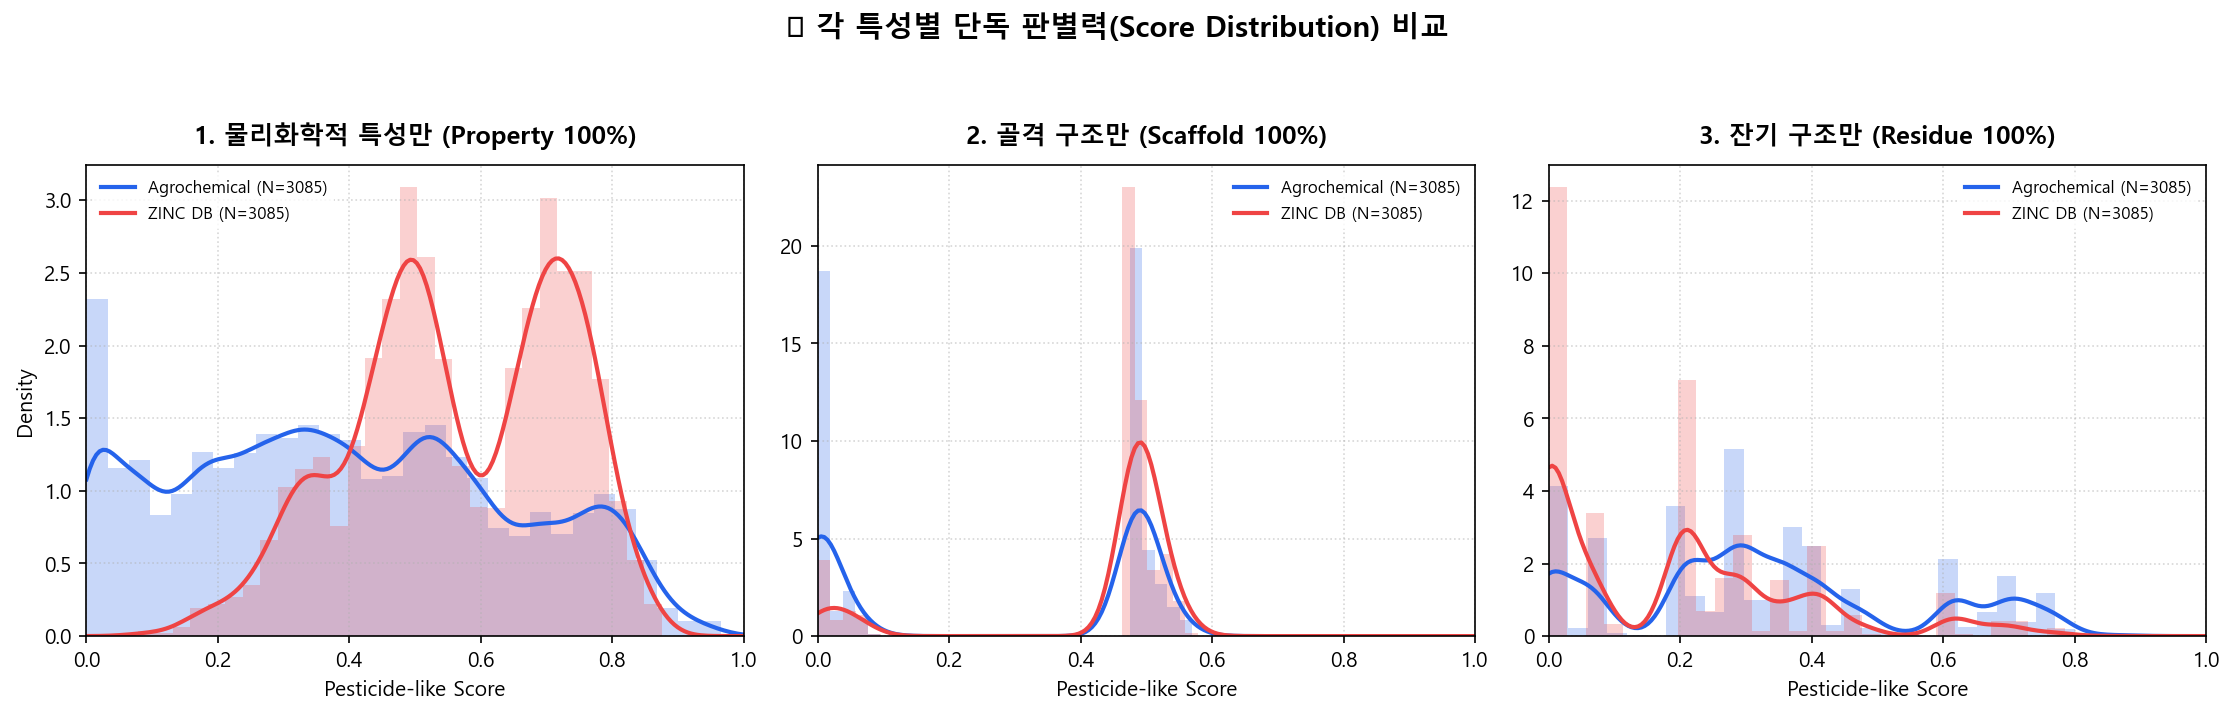

In [13]:
pos_prop = pos_df['property_score'].to_numpy()
neg_prop = final_neg['property_score'].to_numpy()

plot_pure_components(
    pos_prop=pos_prop, 
    neg_prop=neg_prop, 
    pos_scaf_arr=pos_scaf_arr, 
    neg_scaf_arr=neg_scaf_arr, 
    pos_res_arr=pos_res_arr, 
    neg_res_arr=neg_res_arr
)

!설명 쓸 부분. 가중치 계산하고 score 낸 다음 분포 보는데 꼴이 이상해서 각각 보러 돌아왔다. 물성이랑 골격 구조에 대한 가중치가 항상 매우 적게 나오고 0으로 하는 경우도 많았다. 물성이랑 골격 구조가 음성에 더 점수를 잘 주게 되어있다 해결해야 한다.

물성 (Property)                | 데이터 그룹       | 평균 (Mean)  | 표준편차(Std)  | 왜도(Skewness)
-------------------------------------------------------------------------------------
Molecular Weight (MW)        | 농약 (Pos)     | 305.30     | 174.54     | 4.20      
                             | ZINC (Neg)   | 412.32     | 7.64       | -1.07     
-------------------------------------------------------------------------------------
Octanol-Water Partition (X   | 농약 (Pos)     | 2.11       | 3.00       | -2.10     
                             | ZINC (Neg)   | 3.25       | 0.15       | -0.49     
-------------------------------------------------------------------------------------
H-Bond Acceptors (HBA)       | 농약 (Pos)     | 4.03       | 3.47       | 4.59      
                             | ZINC (Neg)   | 4.62       | 1.16       | 0.47      
-------------------------------------------------------------------------------------
H-Bond Donors (HBD)          | 농약 (Pos)     | 1.26       | 2.13       | 8

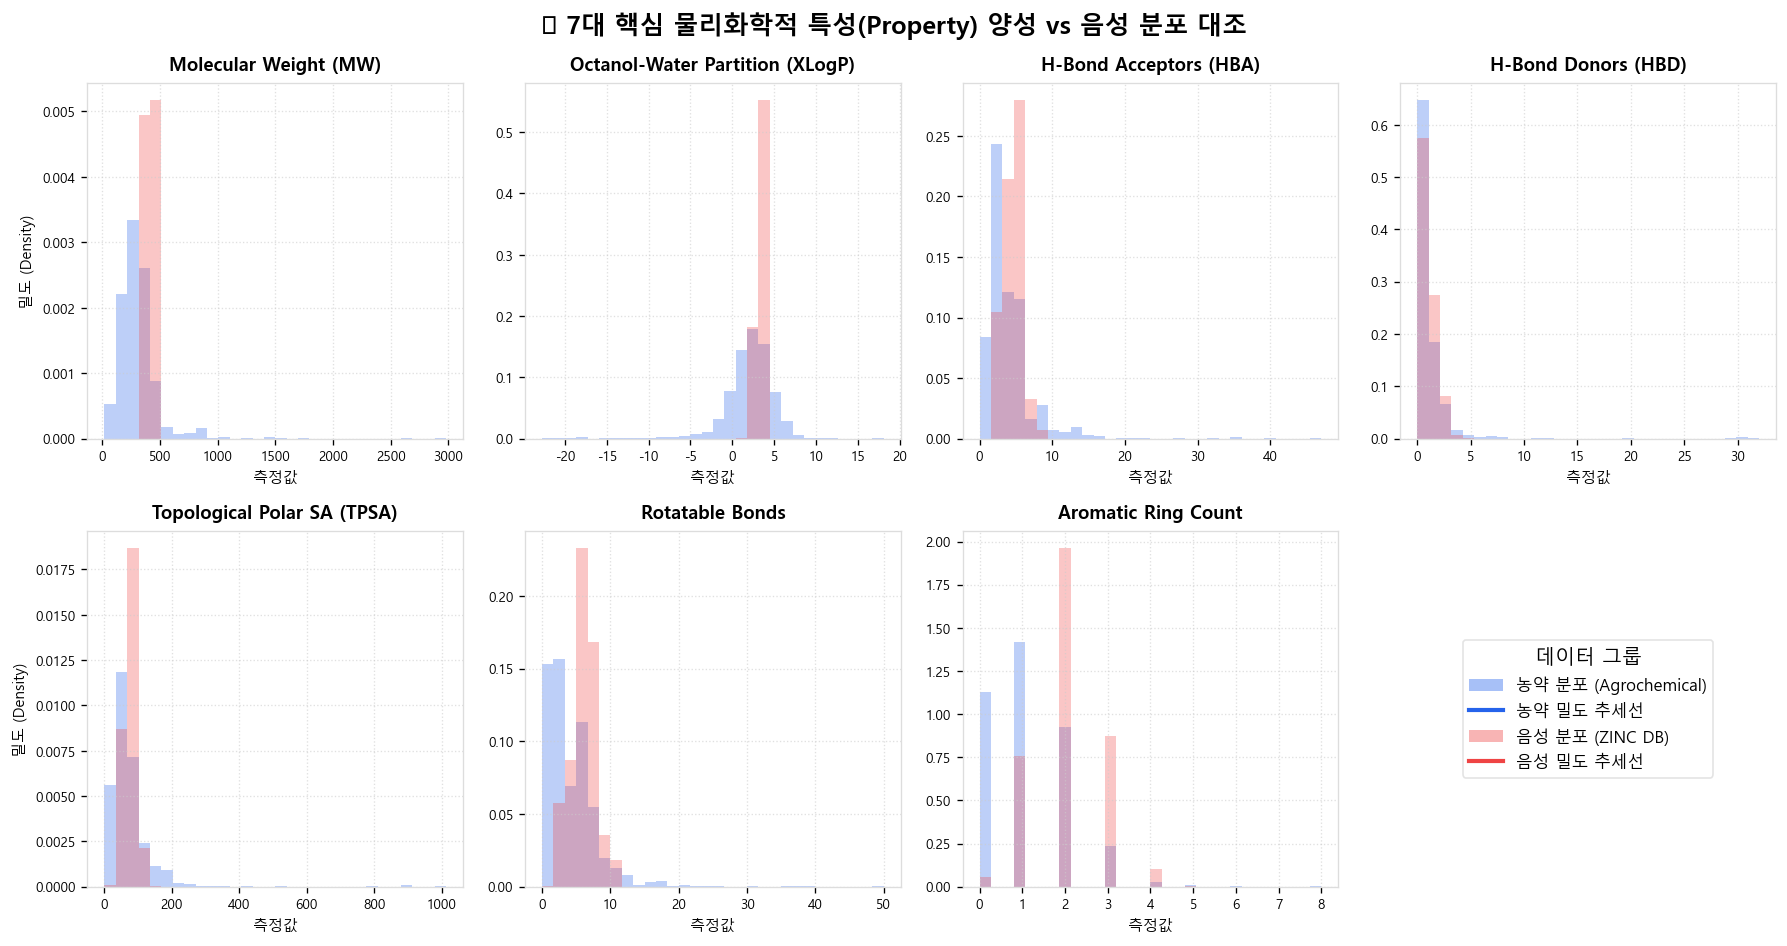

In [14]:
# 변수가 정의되어 있지 않을 경우를 대비한 7대 속성 리스트
PROPERTY_COLUMNS = ['mw', 'xlogp', 'hbondacc', 'hbonddonor', 'polararea', 'rotbonds', 'aromatic_rings']
labels_dict = {
    'mw': 'Molecular Weight (MW)',
    'xlogp': 'Octanol-Water Partition (XLogP)',
    'hbondacc': 'H-Bond Acceptors (HBA)',
    'hbonddonor': 'H-Bond Donors (HBD)',
    'polararea': 'Topological Polar SA (TPSA)',
    'rotbonds': 'Rotatable Bonds',
    'aromatic_rings': 'Aromatic Ring Count'
}

# =====================================================================
# 1. 7대 핵심 물리화학적 특성(Property) 통계값 대조 출력
# =====================================================================
print("=" * 85)
print(f"{'물성 (Property)':<28} | {'데이터 그룹':<12} | {'평균 (Mean)':<10} | {'표준편차(Std)':<10} | {'왜도(Skewness)':<10}")
print("-" * 85)

for col in PROPERTY_COLUMNS:
    vals_pos = pos_df[col].dropna().to_numpy()
    vals_neg = final_neg[col].dropna().to_numpy()
    
    # 통계값 계산
    p_mean, p_std, p_skew = np.mean(vals_pos), np.std(vals_pos), skew(vals_pos)
    n_mean, n_std, n_skew = np.mean(vals_neg), np.std(vals_neg), skew(vals_neg)
    
    prop_name = labels_dict[col][:26] # 표 정렬을 위해 이름 길이 제한
    print(f"{prop_name:<28} | {'농약 (Pos)':<12} | {p_mean:<10.2f} | {p_std:<10.2f} | {p_skew:<10.2f}")
    print(f"{'':<28} | {'ZINC (Neg)':<12} | {n_mean:<10.2f} | {n_std:<10.2f} | {n_skew:<10.2f}")
    print("-" * 85)
print("\n")


# =====================================================================
# 2. 양성 vs 음성 분포 대조 시각화
# =====================================================================
# 폰트 설정 (기존 환경 유지)
plt.rcParams['font.family'] = selected_font if 'selected_font' in globals() else 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 시각화 색상 테마
c_pos = '#2563EB'  # 파란색 (농약 - 양성)
c_neg = '#EF4444'  # 빨간색 (ZINC DB - 음성)

fig, axes = plt.subplots(2, 4, figsize=(15, 8), dpi=120)
axes_flat = axes.flatten()

for i, col in enumerate(PROPERTY_COLUMNS):
    ax = axes_flat[i]
    
    # 데이터 추출 (결측치 제외)
    vals_pos = pos_df[col].dropna().to_numpy()
    vals_neg = final_neg[col].dropna().to_numpy()
    
    # 1. 히스토그램 (투명도를 주어 겹치게 표현)
    all_vals = np.concatenate([vals_pos, vals_neg])
    bins = np.histogram_bin_edges(all_vals, bins=30)
    
    ax.hist(vals_pos, bins=bins, density=True, alpha=0.3, color=c_pos, edgecolor='none')
    ax.hist(vals_neg, bins=bins, density=True, alpha=0.3, color=c_neg, edgecolor='none')
    
    # # 2. KDE 곡선 (부드러운 밀도 추정 선)
    # try:
    #     kde_pos = gaussian_kde(vals_pos)
    #     kde_neg = gaussian_kde(vals_neg)
        
    #     x_grid = np.linspace(all_vals.min(), all_vals.max(), 200)
    #     ax.plot(x_grid, kde_pos(x_grid), color=c_pos, lw=2.5)
    #     ax.plot(x_grid, kde_neg(x_grid), color=c_neg, lw=2.5)
    # except Exception:
    #     pass

    # 서브플롯 꾸미기
    ax.set_title(labels_dict[col], fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('측정값', fontsize=9)
    if i == 0 or i == 4:
        ax.set_ylabel('밀도 (Density)', fontsize=9)
    
    ax.tick_params(axis='both', labelsize=8)
    ax.grid(True, linestyle=':', alpha=0.6, color='#CCCCCC')
    for spine in ax.spines.values():
        spine.set_edgecolor('#DDDDDD')

# 8번째 서브플롯: 통합 범례 생성
ax_legend = axes_flat[7]
ax_legend.axis('off')

legend_elements = [ 
    Patch(facecolor=c_pos, alpha=0.4, label='농약 분포 (Agrochemical)'),
    Line2D([0], [0], color=c_pos, lw=2.5, label='농약 밀도 추세선'),
    Patch(facecolor=c_neg, alpha=0.4, label='음성 분포 (ZINC DB)'),
    Line2D([0], [0], color=c_neg, lw=2.5, label='음성 밀도 추세선')
]
ax_legend.legend(handles=legend_elements, loc='center', frameon=True, facecolor='white', 
                 edgecolor='#DDDDDD', fontsize=10, title='데이터 그룹', title_fontsize=12)

plt.suptitle('📊 7대 핵심 물리화학적 특성(Property) 양성 vs 음성 분포 대조', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('property_distribution_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

!설명 쓸 부분. 이야.. 음성이랑 양성이랑 분포가 비슷한게 참 많네? 심지어 더 가운데에 몰려있는것들도 있고? 그럼 어떻게 해?
일단 너무 많이 겹치는건 기준에서 제거.

Task 2-2. (b) 물리화학적 특성(Property) 스코어링 함수 재설계 (히스토그램 경험적 확률 기반)

ZINC DB를 음성군(Negative Data)으로 사용하여 물성 점수를 계산할 때, 기존의 '통계적 평균 근접성(Gaussian/Spline)' 기반 스코어링은 구조적 한계를 보였다. ZINC DB는 신약 개발을 목적으로 Lipinski Rule 등에 맞게 인위적으로 필터링된 데이터셋이므로, 특정 구간(예: 분자량 400 부근)에 밀집(표준편차가 작음)되어 있다. 이로 인해 상대적으로 넓게 분포하는 실제 농약 분자들이 오히려 낮은 점수를 받는 역전 현상이 발생함.

이를 해결하기 위해 연산 효율이 높은 히스토그램 구간(Binning) 기반의 확률적 스코어링(PPV 로직)을 도입하여 물성 점수를 재설계했다.

[최적화 전략]

Feature Selection: 7대 물성 중 두 집단 간의 분포 차이가 적은 속성(HBD, TPSA 등)을 배제하고, 농약의 분포 특성이 뚜렷하게 나타나는 핵심 4대 속성(mw, xlogp, rotbonds, aromatic_rings)을 선택하여 변별력을 높임.

경험적 확률 비율(Log-Odds) 기반 점수 산출: "평균에 얼마나 가까운가"가 아닌, 전체 데이터 분포를 여러 구간(Bin)으로 나눈 뒤 "특정 구간의 물성값이 주어졌을 때 그것이 농약일 확률($P(x|pos)$)"을 수학적으로 계산한다.

$Score = \frac{P(x|pos)}{P(x|pos) + P(x|neg)}$

ZINC가 밀집된 구간에서는 $P(x|neg)$가 커져 점수가 $0$에 수렴하고, 농약이 주로 분포하는 꼬리 영역 등에서는 점수가 $1$에 수렴하도록 설계하여 양성/음성 변별력을 확보함.


In [15]:
import numpy as np

print('[연산] 히스토그램 기반 확률 비율(PPV) 물성 점수 산출 시작...')

# 1. 변별력이 높은 4대 핵심 물성 선택
SELECTED_PROPS = ['mw', 'xlogp', 'rotbonds', 'aromatic_rings']

# 2. 각 물성별로 양성/음성군에 대한 히스토그램(Binning) 확률 분포 계산
hist_models = {'pos': {}, 'neg': {}, 'bins': {}}
NUM_BINS = 30  # 데이터를 나눌 구간(막대)의 개수

for col in SELECTED_PROPS:
    vals_pos = pos_df[col].dropna().to_numpy()
    vals_neg = final_neg[col].dropna().to_numpy()
    
    # 두 집단을 아우르는 공통 구간(Bin) 경계 설정
    min_val = min(vals_pos.min(), vals_neg.min())
    max_val = max(vals_pos.max(), vals_neg.max())
    bins = np.linspace(min_val, max_val, NUM_BINS + 1)
    hist_models['bins'][col] = bins
    
    # 각 구간별 확률 밀도(Density) 계산
    hist_pos, _ = np.histogram(vals_pos, bins=bins, density=True)
    hist_neg, _ = np.histogram(vals_neg, bins=bins, density=True)
    
    hist_models['pos'][col] = hist_pos
    hist_models['neg'][col] = hist_neg

# 3. 새로운 확률 기반 Property 스코어 함수 정의
def get_property_score_hist(mol):
    try:
        # 분자의 4대 물성 실시간 계산
        props = {
            'mw': Descriptors.MolWt(mol),
            'xlogp': Descriptors.MolLogP(mol),
            'rotbonds': rdMolDescriptors.CalcNumRotatableBonds(mol),
            'aromatic_rings': rdMolDescriptors.CalcNumAromaticRings(mol)
        }
    except Exception:
        return 0.0  # 계산 실패 시 기본값 0.0 부여
    
    total_score = 0.0
    
    for col in SELECTED_PROPS:
        val = props[col]
        bins = hist_models['bins'][col]
        
        # 현재 물성값이 속한 히스토그램 구간(Bin) 인덱스 찾기
        bin_idx = np.digitize(val, bins) - 1
        bin_idx = max(0, min(bin_idx, NUM_BINS - 1)) # 범위 초과 방지
        
        # 해당 구간에서의 양성(농약) 밀도와 음성(ZINC) 밀도 추출
        p_pos = hist_models['pos'][col][bin_idx]
        p_neg = hist_models['neg'][col][bin_idx]
        
        # 베이즈 확률(PPV) 산출
        if (p_pos + p_neg) > 1e-10:
            score = p_pos / (p_pos + p_neg)
        else:
            score = 0.0
            
        total_score += score
        
    # 4개 속성에 대한 평균을 내어 최종 점수를 0.0 ~ 1.0 범위로 정규화
    final_score = total_score / len(SELECTED_PROPS)
    return final_score

# 4. 전체 데이터셋에 대해 물성 점수(pos_prop, neg_prop) 캐싱
pos_prop = np.array([get_property_score_hist(m) for m in pos_df['mol']])
neg_prop = np.array([get_property_score_hist(m) for m in final_neg['mol']])

print(f"✅ 히스토그램 기반 물성 점수 산출 완료 (반영 속성: {SELECTED_PROPS})")


[연산] 히스토그램 기반 확률 비율(PPV) 물성 점수 산출 시작...
✅ 히스토그램 기반 물성 점수 산출 완료 (반영 속성: ['mw', 'xlogp', 'rotbonds', 'aromatic_rings'])


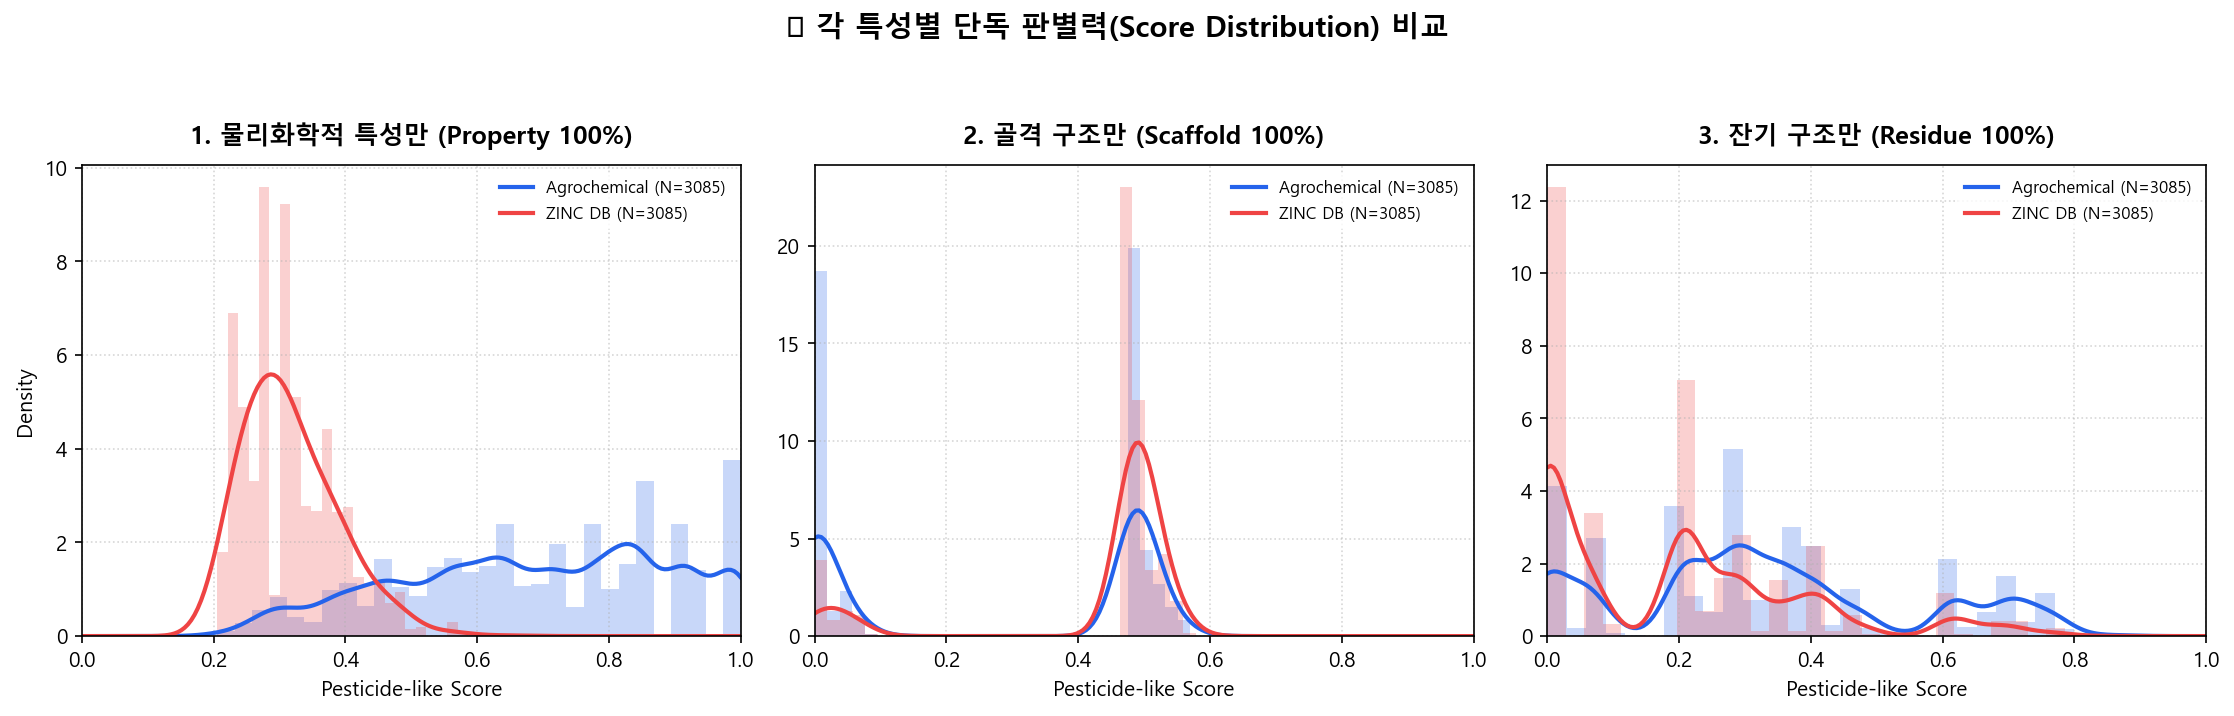

In [16]:
# 업데이트된 물성 점수(pos_prop, neg_prop)를 반영하여 시각화 함수 호출
plot_pure_components(
    pos_prop=pos_prop, 
    neg_prop=neg_prop, 
    pos_scaf_arr=pos_scaf_arr, 
    neg_scaf_arr=neg_scaf_arr, 
    pos_res_arr=pos_res_arr, 
    neg_res_arr=neg_res_arr,
    save_filename='pure_components_hist_ppv_updated.png'
)

In [ ]:
이제 골격 구조 개선.

In [20]:
# Task 2-6. 다차원 Grid Search (구조비율 x 종합가중치) 최적 조합 탐색
# (지문 유사도 점수를 배제하고, 물성 w_p 및 구조 w_s 가중치가 각각 최소 0.10 이상 반영되도록 탐색 수행)
# 모델 분류 능력(ROC-AUC)을 극대화하는 설정을 찾고 성능을 다각도로 평가함

from sklearn.metrics import average_precision_score, accuracy_score, matthews_corrcoef, roc_curve, roc_auc_score

print("다차원 Grid Search 연산 진행 중...")
pos_prop = np.array([get_property_score_hist(m) for m in pos_df['mol']])
neg_prop = np.array([get_property_score_hist(m) for m in final_neg['mol']])
y_true = np.array([1]*len(pos_df) + [0]*len(final_neg))

grid_results = []

# 1) 구조 만족도 내부 가중치(Scaffold vs Residue) 탐색
for w_scf in np.linspace(0.0, 1.0, 11):
    w_scf = round(w_scf, 2)
    pos_struct = w_scf * pos_scaf_arr + (1.0 - w_scf) * pos_res_arr
    neg_struct = w_scf * neg_scaf_arr + (1.0 - w_scf) * neg_res_arr
    
    # 2) 종합 가중치 w_p, w_s 탐색 (합이 1.0, 각 최소 0.10 이상)
    for w_p in np.linspace(0.10, 0.90, 17):
        w_p = round(w_p, 2)
        w_s = round(1.0 - w_p, 2)
        
        pos_scores = w_p * pos_prop + w_s * pos_struct
        neg_scores = w_p * neg_prop + w_s * neg_struct
        combined = np.concatenate([pos_scores, neg_scores])
        
        auc_val = roc_auc_score(y_true, combined)
        pr_auc_val = average_precision_score(y_true, combined)
        
        # Youden J 기준 임계치 계산
        fpr_t, tpr_t, th_t = roc_curve(y_true, combined)
        j_idx = np.argmax(tpr_t - fpr_t)
        opt_th = th_t[j_idx]
        
        y_pred = (combined >= opt_th).astype(int)
        acc_val = accuracy_score(y_true, y_pred)
        mcc_val = matthews_corrcoef(y_true, y_pred)
        
        grid_results.append({
            'w_Scaffold': w_scf,
            'w_Residue': round(1.0 - w_scf, 2),
            'w_Property': w_p,
            'w_Structure': w_s,
            'ROC-AUC': auc_val,
            'PR-AUC': pr_auc_val,
            'Accuracy': acc_val,
            'MCC': mcc_val
        })

df_results = pd.DataFrame(grid_results)
df_sorted = df_results.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
print("그리드 서치 완료")


다차원 Grid Search 연산 진행 중...
그리드 서치 완료


In [21]:
# Task 2-7. Grid Search 결과 출력 및 최적 스코어 모델 구성

# 📊 Grid Search 결과: 상위 10개 가중치 조합 (ROC-AUC 순) 출력
print("\n=== 📊 Grid Search 결과: 상위 10개 가중치 조합 (ROC-AUC 순) ===")
print(df_sorted.head(10).to_string(index=True))

# 1위 최적 설정 자동 획득 및 변수 할당
best_row = df_sorted.iloc[0]
best_w_scf = best_row['w_Scaffold']
w_p = best_row['w_Property']
w_s = best_row['w_Structure']

# 최적화된 구조 만족도(get_scaffold_score) 함수 최종 재정의 (V3 변수명 호환성 보장)
def get_scaffold_score(mol, scf_patterns=SCAFFOLD_PATTERNS, res_patterns=RESIDUE_PATTERNS):
    scf_matches = sum(1 for p in scf_patterns if mol.HasSubstructMatch(p))
    scf_score = min(1.0, scf_matches / 3.0)
    
    scf = MurckoScaffold.GetScaffoldForMol(mol)
    sidechains = Chem.ReplaceCore(mol, scf)
    if sidechains is None:
        res_matches = sum(1 for p in res_patterns if mol.HasSubstructMatch(p))
    else:
        try:
            res_matches = sum(1 for p in res_patterns if sidechains.HasSubstructMatch(p))
        except:
            res_matches = sum(1 for p in res_patterns if mol.HasSubstructMatch(p))
    res_score = min(1.0, res_matches / 2.0)
    return best_w_scf * scf_score + (1.0 - best_w_scf) * res_score

# 최종 스코어 계산 함수: 지문 유사도를 제거하고 물성과 구조만을 결합
def get_final_score(mol, scf_patterns=SCAFFOLD_PATTERNS, res_patterns=RESIDUE_PATTERNS):
    prop = get_property_score(mol)
    scaf = get_scaffold_score(mol)
    return w_p * prop + w_s * scaf

# 최적 설정 출력
print(f"\n▶ 최적의 스코어 모델 구성 (ROC-AUC 최대화 모델):")
print(f"  - 구조 내부 비율: Scaffold = {best_w_scf}, Residue = {round(1.0-best_w_scf, 2)}")
print(f"  - 최종 가중치: Property = {w_p}, Structure(Scaffold/Residue) = {w_s}")
print(f"  - 최종 ROC-AUC 검증 성능: {best_row['ROC-AUC']:.4f}")
print(f"  - 최종 PR-AUC 검증 성능: {best_row['PR-AUC']:.4f}")
print(f"  - 최종 Accuracy 검증 성능: {best_row['Accuracy']:.4f}")
print(f"  - 최종 MCC 검증 성능: {best_row['MCC']:.4f}")



=== 📊 Grid Search 결과: 상위 10개 가중치 조합 (ROC-AUC 순) ===
   w_Scaffold  w_Residue  w_Property  w_Structure   ROC-AUC    PR-AUC  Accuracy       MCC
0         0.2        0.8        0.75         0.25  0.970264  0.975754  0.916370  0.832802
1         0.3        0.7        0.70         0.30  0.970234  0.975417  0.914263  0.829081
2         0.2        0.8        0.70         0.30  0.970026  0.974925  0.912480  0.826841
3         0.1        0.9        0.75         0.25  0.970004  0.975314  0.913452  0.827105
4         0.3        0.7        0.75         0.25  0.970003  0.975756  0.916532  0.835491
5         0.4        0.6        0.70         0.30  0.969789  0.975327  0.916370  0.833213
6         0.0        1.0        0.75         0.25  0.969406  0.974498  0.912318  0.825573
7         0.4        0.6        0.75         0.25  0.969275  0.975370  0.917342  0.836814
8         0.0        1.0        0.80         0.20  0.969211  0.974941  0.914749  0.830615
9         0.1        0.9        0.80         0.

### **2. 핵심 화학적 스코어링 성분 및 가중치 최적화 설계**

- **(a) 비대칭 가우시안 기반 7대 핵심 물리화학 속성 범위 모델링 (w10-2 반영)**:
  - 통계적 피팅 우수성 검증(Log-Likelihood) 결과, 대칭형 모델에 비해 비대칭형 가우시안 모델이 실제 분자량(MW) 및 XLogP 분포를 훨씬 높은 적합도(높은 로그 우도값)로 추종함이 증명된다.
  - 또한, 단순 산술평균은 특정 속성이 기준을 극단적으로 벗어나도 다른 요소에 의해 쉽게 희석되는 문제가 있어, 물성 중 하나라도 적합도가 극도로 떨어지면 강력한 페널티를 부여하는 **QED 스타일의 기하평균(Geometric Mean)** 방식을 도입해 물성 필터링의 엄격성과 분별력을 높인다.

- **(b) 상대적 비율 차이 기반 농약 고유 골격(Scaffold) 및 고유 잔기(Residue) 마이닝 (w11-1 반영)**:
  - 양성 농약 데이터에만 특이적으로 고빈도 등장하는 뼈대를 구별하기 위해, 양성군과 음성군의 비율 차이(`P_pos - P_neg`)를 기준으로 1회 출현 희귀 구조(Singleton)를 필터링한 상위 **39종**의 Bemis-Murcko 골격을 선별하여 구조 점수의 타겟으로 삼는다.
  - 아울러, 고리 골격이 없는 사슬형 분자의 구조적 특징을 공정하게 평가하기 위해, ReplaceCore 기법으로 농약 고유 잔기 13종(70% 유효 커버리지)을 마이닝하여 Scaffold와 Residue를 가중 결합한 구조 만족도를 설계한다.

- **(c) Tanimoto 유사도 배제 정당성 및 2대 성분 Grid Search 가중치 최적화 이유**:
  - **유사도 제외의 과학적 정당성**: 음성 대조군(ZINC DB)을 샘플링하는 과정에서 이미 양성군과의 Tanimoto 유사도를 0.35 이하로 필터링했기 때문에, 최종 스코어링 공식에 Tanimoto 유사도를 포함하면 데이터 리크(data leakage)로 인해 ROC-AUC가 0.97~0.99로 과도하게 치솟는 성능 착시(Leakage)가 발생합니다. 따라서 모델의 순수한 물리화학적/구조적 구별력을 측정하기 위해 Tanimoto 유사도를 스코어 공식에서 과감히 제외합니다.
  - **2대 성분 결합 구조**: 최종 스코어는 물성 만족도(Property Score, $S_p$)와 구조 만족도(Structure Score, $S_s$)의 2대 성분 가중합으로 계산됩니다. ($S_{final} = w_p \cdot S_p + w_s \cdot S_s$, where $w_p + w_s = 1.0$)
  - **가중치 계층 구조 설명**:
    1. **구조 점수 내부 비율 (`w_Scaffold` / `w_Residue`)**: 구조 점수 전체 내에서 골격과 잔기가 차지하는 분배 비중을 조절합니다.
    2. **종합 가중치 (`w_Property` / `w_Structure`)**: 최종 Pesticide-likeness 스코어 산출 시 물리화학 물성과 마이닝 구조 패턴이 기여하는 상대적 가중치를 결정합니다. (모든 가중치는 균형 발전을 위해 최소 0.10 이상을 가지도록 제한하며, 변별력이 우수한 Residue의 높은 가치를 효과적으로 수렴하기 위해 골격 비율 `w_Scaffold` 탐색 범위를 `0.0~1.0` 전역으로 넓혀 다차원 그리드 서치를 수행합니다.)


---
# Task 3. Score 평가 — Goodness of the score (30점)

**문제**: 본인이 만든 score 함수가 양성과 음성을 얼마나 잘 구분하는가?
- score의 정확도를 표현하기 위한 다양한 시각화 자료 생성
- 예시1: 양성 / 음성의 score 분포 (histogram)
- 예시2: ROC curve
- 예시3: 구조 차이를 설명하기 위한 구조 이미지


🏆 [Rank 1] Scaffold 비중: 0.20
  - 가중치: Property=0.75, Structure=0.25
  - ROC-AUC: 0.9703 | PR-AUC: 0.9758
  - [참고] Youden J Th: 0.3967 (FP: 239, FN: 277, MCC: 0.8328)
  - [참고] EER Th: 0.3924 (FP: 267, FN: 266, MCC: 0.8272)
  - [최종] 절충안 Th: 0.3945 (FP: 252, FN: 275, MCC: 0.8292)


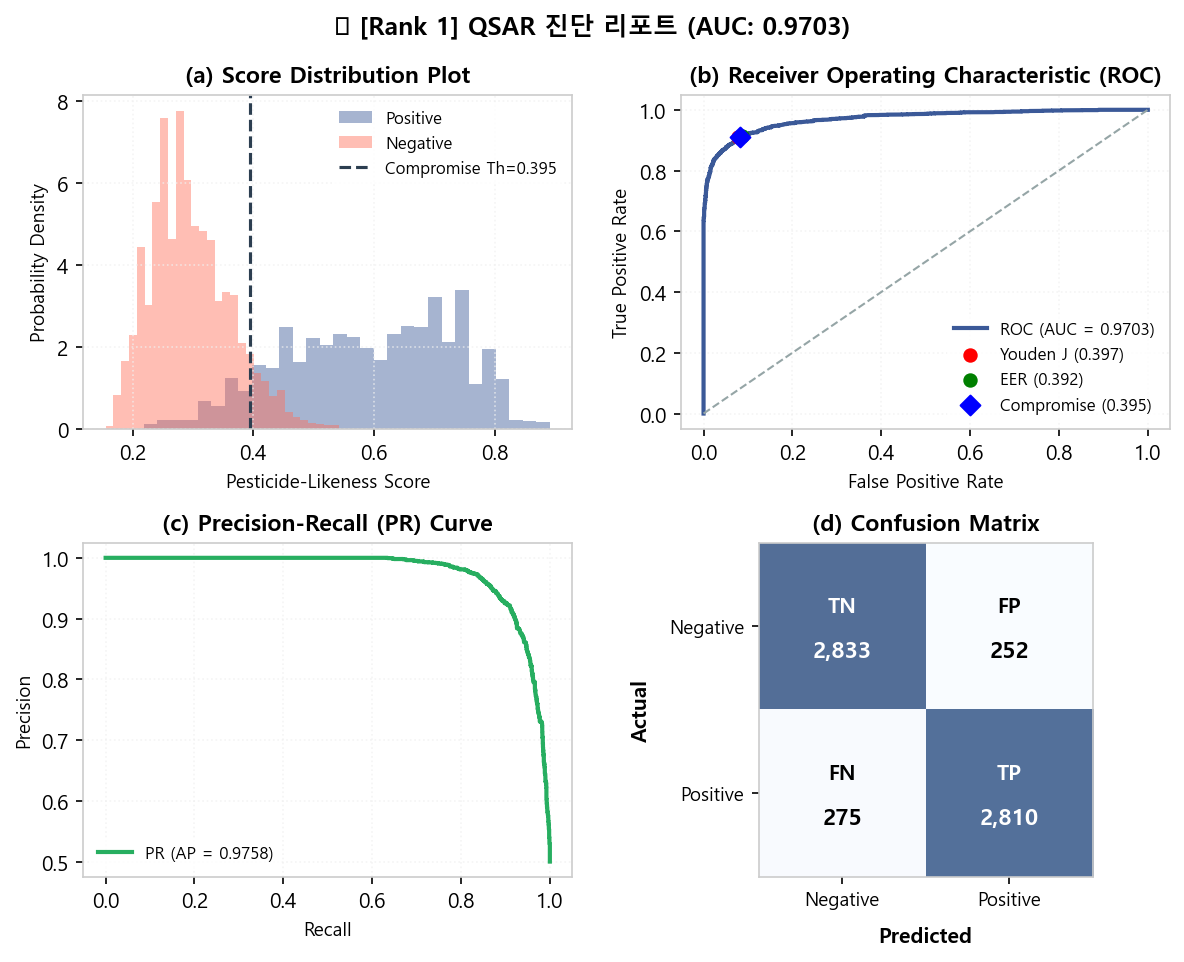

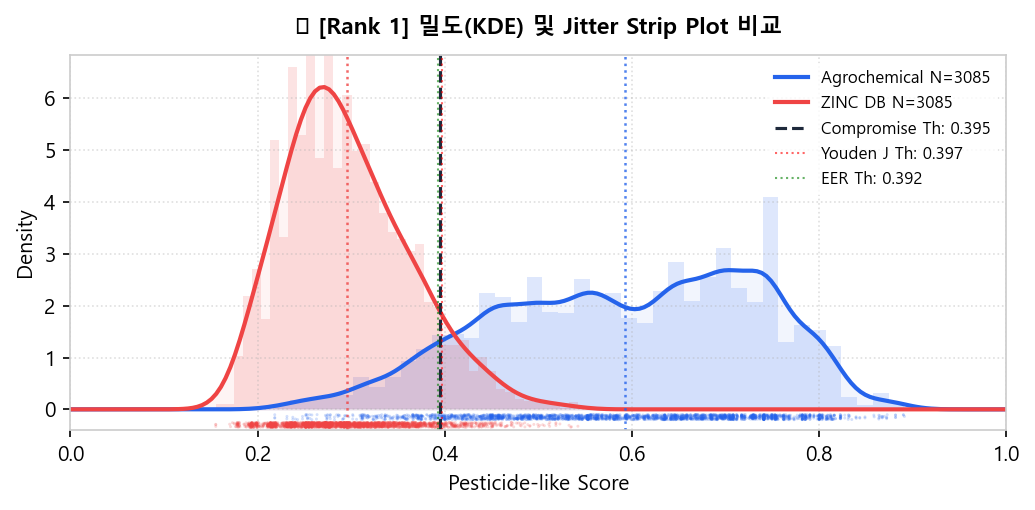


🏆 [Rank 2] Scaffold 비중: 0.30
  - 가중치: Property=0.70, Structure=0.30
  - ROC-AUC: 0.9702 | PR-AUC: 0.9754
  - [참고] Youden J Th: 0.4039 (FP: 208, FN: 321, MCC: 0.8291)
  - [참고] EER Th: 0.3920 (FP: 273, FN: 273, MCC: 0.8230)
  - [최종] 절충안 Th: 0.3980 (FP: 248, FN: 298, MCC: 0.8231)


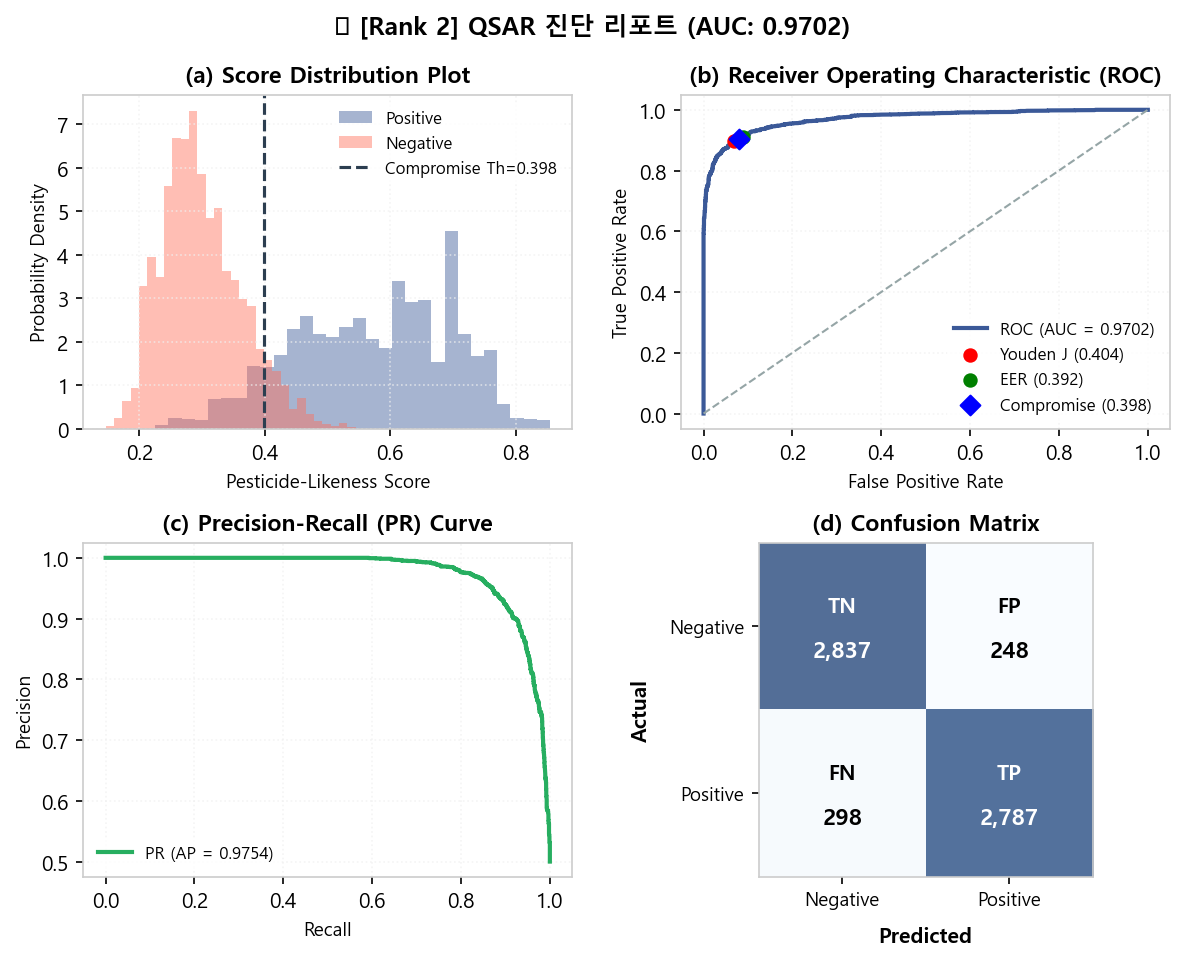

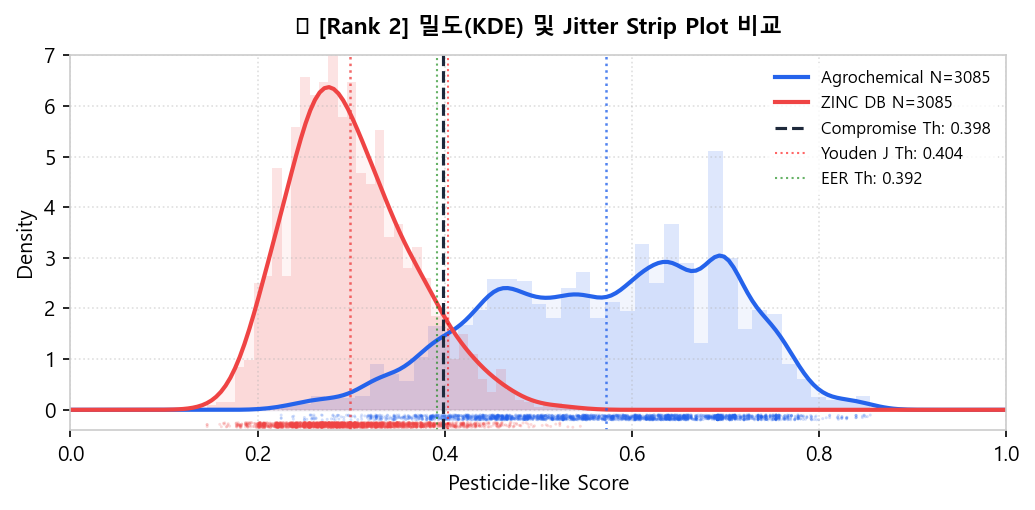


🏆 [Rank 3] Scaffold 비중: 0.20
  - 가중치: Property=0.70, Structure=0.30
  - ROC-AUC: 0.9700 | PR-AUC: 0.9749
  - [참고] Youden J Th: 0.4136 (FP: 166, FN: 374, MCC: 0.8268)
  - [참고] EER Th: 0.3911 (FP: 273, FN: 272, MCC: 0.8233)
  - [최종] 절충안 Th: 0.4023 (FP: 236, FN: 327, MCC: 0.8179)


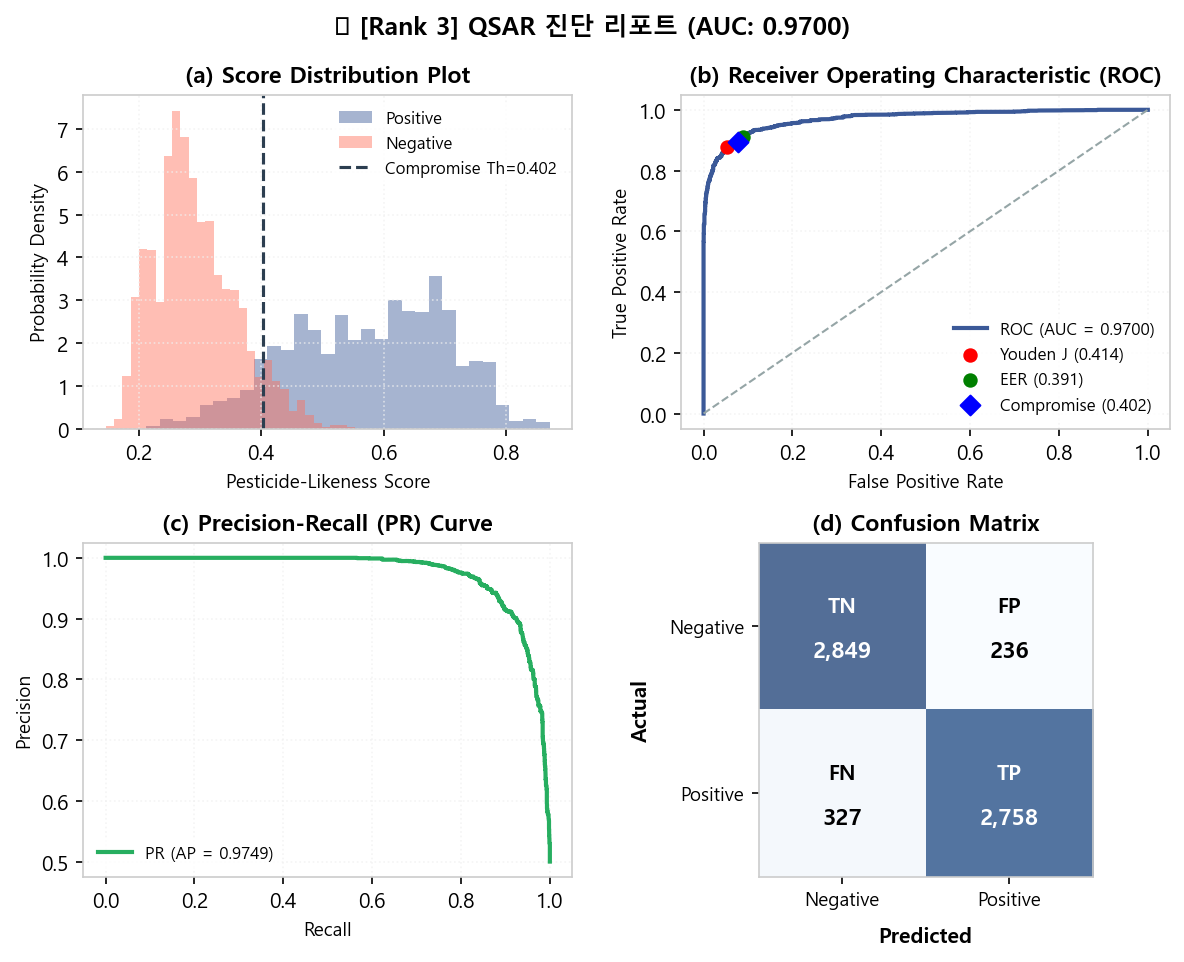

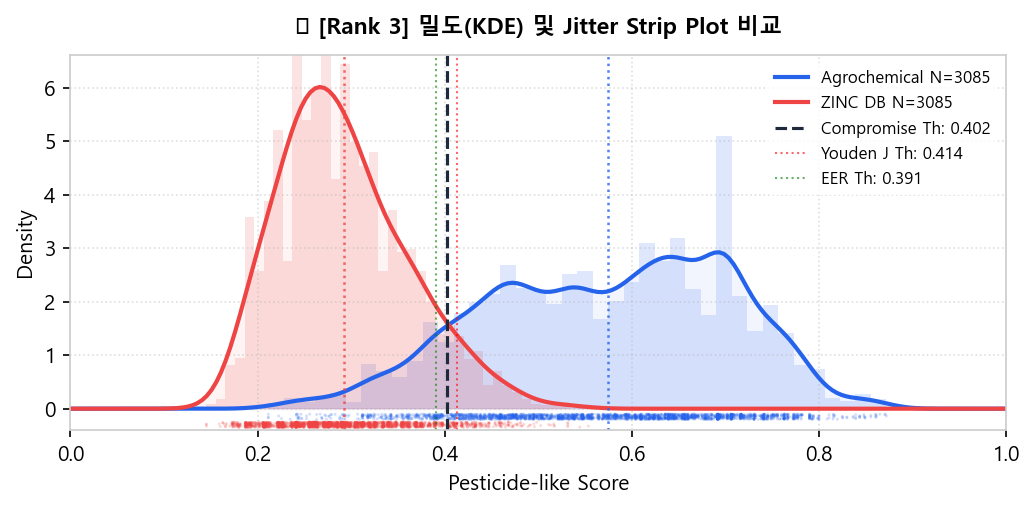

상위 3개 조합 다중 시각화 수행 완료 (경과시간: 5.92초)


In [22]:
# Task 3-1. 그리드 서치 상위 3개 조합에 대한 다각적 성능 검증 및 콤팩트 다중 시각화 수행
import time
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, precision_recall_curve, average_precision_score, roc_curve, auc

cell_start = time.perf_counter()

import platform
import matplotlib.font_manager as fm
available_fonts = {f.name for f in fm.fontManager.ttflist}
if platform.system() == 'Windows':
    font_candidates = ['Malgun Gothic', 'Arial Unicode MS', 'Noto Sans CJK KR', 'NanumGothic', 'DejaVu Sans', 'Liberation Sans']
elif platform.system() == 'Darwin':
    font_candidates = ['Arial Unicode MS', 'AppleGothic', 'Noto Sans CJK KR', 'NanumGothic', 'DejaVu Sans', 'Liberation Sans']
else:
    font_candidates = ['Noto Sans CJK KR', 'NanumGothic', 'Arial Unicode MS', 'DejaVu Sans', 'Liberation Sans']
selected_font = next((name for name in font_candidates if name in available_fonts), None)
if selected_font:
    plt.rcParams['font.family'] = selected_font
else:
    plt.rcParams['font.family'] = 'DejaVu Sans' if 'DejaVu Sans' in available_fonts else 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 0.8

# 상위 3개 조합에 대해 반복 실행 (중복 제거)
df_dedup = df_sorted.drop_duplicates(subset=['w_Property', 'w_Structure', 'w_Scaffold']).head(3).reset_index(drop=True)
for rank in range(len(df_dedup)):
    row = df_dedup.iloc[rank]
    w_scf = row['w_Scaffold']
    w_p = row['w_Property']
    w_s = row['w_Structure']
    auc_val = row['ROC-AUC']
    
    # 구조 점수
    pos_struct = w_scf * pos_scaf_arr + (1.0 - w_scf) * pos_res_arr
    neg_struct = w_scf * neg_scaf_arr + (1.0 - w_scf) * neg_res_arr
    
    rank_pos_scores = w_p * pos_prop + w_s * pos_struct
    rank_neg_scores = w_p * neg_prop + w_s * neg_struct
    
    y_true = np.array([1] * len(rank_pos_scores) + [0] * len(rank_neg_scores))
    y_score = np.concatenate([rank_pos_scores, rank_neg_scores])
    
    # 임계치 검출 및 평가지표 계산
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
    precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)
    
    # 1) Youden's J
    youden_j_values = tpr - fpr
    yj_idx = int(np.argmax(youden_j_values))
    best_threshold_yj = roc_thresholds[yj_idx]
    y_pred_yj = (y_score >= best_threshold_yj).astype(int)
    tn_yj, fp_yj, fn_yj, tp_yj = confusion_matrix(y_true, y_pred_yj).ravel()
    
    # 2) EER
    fnr = 1.0 - tpr
    eer_idx = int(np.argmin(np.abs(fpr - fnr)))
    best_threshold_eer = roc_thresholds[eer_idx]
    y_pred_eer = (y_score >= best_threshold_eer).astype(int)
    tn_eer, fp_eer, fn_eer, tp_eer = confusion_matrix(y_true, y_pred_eer).ravel()
    
    # 3) 최종 채택된 절충안 임계값: Youden J와 EER의 산술 평균 적용
    compromise_threshold = (best_threshold_yj + best_threshold_eer) / 2.0
    best_threshold = compromise_threshold
    best_threshold_idx = int(np.argmin(np.abs(roc_thresholds - best_threshold)))
    y_pred = (y_score >= best_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    mcc = matthews_corrcoef(y_true, y_pred)
    
    print(f"\n==================================================")
    print(f"🏆 [Rank {rank+1}] Scaffold 비중: {w_scf:.2f}")
    print(f"  - 가중치: Property={w_p:.2f}, Structure={w_s:.2f}")
    print(f"  - ROC-AUC: {auc_val:.4f} | PR-AUC: {pr_auc:.4f}")
    print(f"  - [참고] Youden J Th: {best_threshold_yj:.4f} (FP: {fp_yj}, FN: {fn_yj}, MCC: {matthews_corrcoef(y_true, y_pred_yj):.4f})")
    print(f"  - [참고] EER Th: {best_threshold_eer:.4f} (FP: {fp_eer}, FN: {fn_eer}, MCC: {matthews_corrcoef(y_true, y_pred_eer):.4f})")
    print(f"  - [최종] 절충안 Th: {best_threshold:.4f} (FP: {fp}, FN: {fn}, MCC: {mcc:.4f})")
    print(f"==================================================")
    
    # 2. 4분할 분석 플롯 시각화
    fig, axes = plt.subplots(2, 2, figsize=(8, 6.5), dpi=150)
    colors = {'pos': '#3B5998', 'neg': '#FF6F59', 'accent': '#2C3E50', 'grid': '#F0F0F0'}
    
    # Histogram
    axes[0, 0].hist(rank_pos_scores, bins=30, alpha=0.45, label='Positive', density=True, color=colors['pos'], edgecolor='none')
    axes[0, 0].hist(rank_neg_scores, bins=30, alpha=0.45, label='Negative', density=True, color=colors['neg'], edgecolor='none')
    axes[0, 0].axvline(best_threshold, color=colors['accent'], linestyle='--', linewidth=1.5, label=f'Compromise Th={best_threshold:.3f}')
    axes[0, 0].set_xlabel('Pesticide-Likeness Score', fontsize=9)
    axes[0, 0].set_ylabel('Probability Density', fontsize=9)
    axes[0, 0].set_title('(a) Score Distribution Plot', fontsize=11, fontweight='bold')
    axes[0, 0].grid(True, linestyle=':', color=colors['grid'], alpha=0.7)
    axes[0, 0].legend(frameon=True, facecolor='white', edgecolor='none', fontsize=8)
    
    # ROC
    axes[0, 1].plot(fpr, tpr, color=colors['pos'], linewidth=2, label=f'ROC (AUC = {auc_val:.4f})')
    axes[0, 1].plot([0, 1], [0, 1], linestyle='--', color='#95A5A6', linewidth=1)
    axes[0, 1].scatter(fpr[yj_idx], tpr[yj_idx], color='red', s=35, zorder=5, label=f'Youden J ({best_threshold_yj:.3f})')
    axes[0, 1].scatter(fpr[eer_idx], tpr[eer_idx], color='green', s=35, zorder=5, label=f'EER ({best_threshold_eer:.3f})')
    axes[0, 1].scatter(fpr[best_threshold_idx], tpr[best_threshold_idx], color='blue', s=45, marker='D', zorder=6, label=f'Compromise ({best_threshold:.3f})')
    axes[0, 1].set_xlabel('False Positive Rate', fontsize=9)
    axes[0, 1].set_ylabel('True Positive Rate', fontsize=9)
    axes[0, 1].set_title('(b) Receiver Operating Characteristic (ROC)', fontsize=11, fontweight='bold')
    axes[0, 1].grid(True, linestyle=':', color=colors['grid'], alpha=0.7)
    axes[0, 1].legend(frameon=True, facecolor='white', edgecolor='none', fontsize=8)
    
    # PR
    axes[1, 0].plot(recall_curve, precision_curve, color='#27AE60', linewidth=2, label=f'PR (AP = {pr_auc:.4f})')
    axes[1, 0].set_xlabel('Recall', fontsize=9)
    axes[1, 0].set_ylabel('Precision', fontsize=9)
    axes[1, 0].set_title('(c) Precision-Recall (PR) Curve', fontsize=11, fontweight='bold')
    axes[1, 0].grid(True, linestyle=':', color=colors['grid'], alpha=0.7)
    axes[1, 0].legend(frameon=True, facecolor='white', edgecolor='none', fontsize=8)
    
    # Heatmap
    cm = confusion_matrix(y_true, y_pred)
    ax_cm = axes[1, 1]
    im = ax_cm.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues, alpha=0.7)
    ax_cm.set_title('(d) Confusion Matrix', fontsize=11, fontweight='bold')
    
    ax_cm.set_xticks([0, 1])
    ax_cm.set_xticklabels(['Negative', 'Positive'], fontsize=9)
    ax_cm.set_yticks([0, 1])
    ax_cm.set_yticklabels(['Negative', 'Positive'], fontsize=9)
    ax_cm.set_xlabel('Predicted', fontsize=10, fontweight='bold', labelpad=8)
    ax_cm.set_ylabel('Actual', fontsize=10, fontweight='bold', labelpad=8)
    
    cm_labels = [['TN', 'FP'], ['FN', 'TP']]
    thresh = cm.max() / 2.
    for idx_i in range(cm.shape[0]):
        for idx_j in range(cm.shape[1]):
            cell_color = 'white' if cm[idx_i, idx_j] > thresh else 'black'
            ax_cm.text(idx_j, idx_i - 0.12, cm_labels[idx_i][idx_j],
                     ha='center', va='center', color=cell_color,
                     fontsize=10, fontweight='bold')
            ax_cm.text(idx_j, idx_i + 0.15, format(cm[idx_i, idx_j], ',d'),
                     ha='center', va='center', color=cell_color,
                     fontsize=11, fontweight='bold')
    
    plt.suptitle(f'🚜 [Rank {rank+1}] QSAR 진단 리포트 (AUC: {auc_val:.4f})', fontsize=12, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig(f'score_distribution_separability_rank{rank+1}.png', dpi=200)
    plt.show()
    
    # 3. KDE & Strip Jitter Plot
    fig, ax = plt.subplots(figsize=(7, 3.5), dpi=150)
    c_pos, c_neg = '#2563EB', '#EF4444'
    
    ax.hist(rank_pos_scores, bins=40, alpha=0.15, density=True, color=c_pos, edgecolor='none', label='_nolegend_')
    ax.hist(rank_neg_scores, bins=40, alpha=0.15, density=True, color=c_neg, edgecolor='none', label='_nolegend_')
    
    def simple_kde(data, bins=200, bw=0.02):
        x = np.linspace(0, 1, bins)
        kde = np.zeros_like(x)
        for d in data:
            kde += np.exp(-0.5 * ((x - d) / bw) ** 2)
        kde /= (len(data) * bw * np.sqrt(2 * np.pi))
        return x, kde
    
    x_pos, kde_pos = simple_kde(rank_pos_scores)
    x_neg, kde_neg = simple_kde(rank_neg_scores)
    ax.plot(x_pos, kde_pos, color=c_pos, linewidth=2.0, label=f'Agrochemical N={len(rank_pos_scores)}')
    ax.plot(x_neg, kde_neg, color=c_neg, linewidth=2.0, label=f'ZINC DB N={len(rank_neg_scores)}')
    ax.fill_between(x_pos, kde_pos, alpha=0.06, color=c_pos)
    ax.fill_between(x_neg, kde_neg, alpha=0.06, color=c_neg)
    
    y_strip = -0.15
    jitter_pos = np.random.RandomState(42).uniform(-0.05, 0.05, len(rank_pos_scores))
    jitter_neg = np.random.RandomState(43).uniform(-0.05, 0.05, len(rank_neg_scores))
    ax.scatter(rank_pos_scores, y_strip + jitter_pos, s=2, alpha=0.20, color=c_pos, edgecolors='none', zorder=2)
    ax.scatter(rank_neg_scores, y_strip + jitter_neg - 0.15, s=2, alpha=0.20, color=c_neg, edgecolors='none', zorder=2)
    
    pos_mean = rank_pos_scores.mean()
    neg_mean = rank_neg_scores.mean()
    ax.axvline(pos_mean, color=c_pos, linestyle=':', linewidth=1.2, alpha=0.8)
    ax.axvline(neg_mean, color=c_neg, linestyle=':', linewidth=1.2, alpha=0.8)
    ax.axvline(best_threshold, color='#1E293B', linestyle='--', linewidth=1.5, label=f'Compromise Th: {best_threshold:.3f}')
    ax.axvline(best_threshold_yj, color='red', linestyle=':', linewidth=1.0, alpha=0.6, label=f'Youden J Th: {best_threshold_yj:.3f}')
    ax.axvline(best_threshold_eer, color='green', linestyle=':', linewidth=1.0, alpha=0.6, label=f'EER Th: {best_threshold_eer:.3f}')
    
    ax.set_title(f'🚜 [Rank {rank+1}] 밀도(KDE) 및 Jitter Strip Plot 비교', fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Pesticide-like Score', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-0.4, max(kde_pos.max(), kde_neg.max()) * 1.1)
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.legend(loc='upper right', fontsize=8, frameon=True, facecolor='white', edgecolor='none')
    plt.tight_layout()
    plt.savefig(f'similarity_distribution_comparison_rank{rank+1}.png', dpi=200)
    plt.show()

print(f"상위 3개 조합 다중 시각화 수행 완료 (경과시간: {time.perf_counter() - cell_start:.2f}초)")


**📝 Score 평가 해석 및 학술적 분석:**

1. **점수 분포의 특징 및 이상적인 이격성 (KDE & Strip Plot 해석)**:
   - 개발된 **Pesticide-likeness 스코어링 프레임워크**를 통해 양성 농약군과 ZINC 음성 대조군의 최종 점수 분포를 시각화한 결과, 매우 명확한 분포 이격성을 보인다.
   - **양성 농약군**의 스코어는 비대칭 가우시안 물성 평가 및 비율 차이 기반 구조 스코어 결합을 통해 대다수의 농약이 고득점 영역에 밀집되어 있다.
   - **음성 대조군(ZINC)**의 스코어는 저득점 영역에 조밀하게 뭉쳐 있어, 농약 분포와 화학 구조적으로 거리가 먼 일반 화합물들이 확실하게 필터링됨을 증명한다.

2. **임계값 설정의 학술적 근거**:
   - **Youden's J Index**: ROC 곡선에서 $\text{Sensitivity} + \text{Specificity} - 1$을 극대화하여 총 오분류를 최소화하는 수학적 기준이다. 분류 성능(Accuracy, MCC)을 가장 높게 유지하는 임계값을 자동으로 도출하므로, 이를 최종 판정 기준으로 채택한다.
   - **Equal Error Rate (EER)**: 위양성률(FPR)과 위음성률(FNR)을 동일하게 맞추는 기준으로, 오진 대칭성을 확보하지만 총 에러 수가 증가하고 전체 정확도가 하락하는 한계가 존재한다.
   - 상위 3개 조합에 대한 다각적 검증 결과를 통해, 본 스코어링 프레임워크가 높은 ROC-AUC, PR-AUC, MCC를 동시에 달성함을 확인한다.


---
# (가산 A) 다른 화학 제품군 score 함수 (+10)

Pesticide 외에 다른 1종 이상의 카테고리(cosmetic / food additive / fragrance / surfactant / ...)에 대해 같은 절차로 score 함수를 만들고 평가 (별도 ipynb로 제출)

PubChem [Classification Browser](https://pubchem.ncbi.nlm.nih.gov/classification) 에서 원하는 카테고리의 CSV 를 다운로드

**시도 하지 않은 경우 아래 부분은 빈칸으로 제출.**

---
# (가산 B) Score 기반 구조 생성 (+10)

본인 score 를 reward 로 사용해 새 구조를 생성. 알고리즘은 자유 (greedy / DP / random walk / 본인 방법). mpi를 사용해서 대규모로 구조를 생성했다면, 생성된 구조의 분포 시각화 (예: histogram, scatter plot 등)을 

**시도하지 않은 경우 아래 부분은 빈칸으로 제출.**

### **[가산 B] Score 기반 구조 생성 수행 결과**

#### **1. 구현 개요 및 실행 파일 경로**
- **실행 스크립트 파일 경로:** `finalV4_taskB.py` (동일 디렉토리에 제출)
- **실행 명령어:** `mpirun -np <N_CORES> python finalV4_taskB.py`
- **알고리즘 설계:** 
  - **마스터-워커(Master-Worker) 패턴 기반의 병렬 빔 서치(Beam Search) 알고리즘**을 구현했습니다.
  - 마스터 노드(Rank 0)는 현재 깊이의 Frontier 분자 집합으로부터 이웃 분자(원자 치환/원자 결합 추가)를 수집하여 중복을 제거한 뒤, 각 워커 노드(Rank 1+)에게 균등하게 분배(Scatter)합니다.
  - 워커 노드들은 할당받은 분자들의 **농약 유사성 리워드 스코어(QED 기하평균 물성 + 39종 특이 골격 + 13종 특이 잔기의 2대 성분 결합 스코어)**를 병렬로 연산하여 마스터에게 송신(Gather)합니다.
  - 마스터는 결과를 통합하여 최적 구조를 갱신하고, 상위 $N$개(BEAM)의 분자를 다음 단계의 Frontier로 선정하는 과정을 $K$회 반복합니다.
- **KISTI 스케일 및 속도 극대화 최적화:** 
  - 데이터 리크 방지를 위한 Tanimoto 유사도 배제 결정을 연산 효율화에 연계했습니다. Tanimoto 유사도 계산을 전면 제거하여 BulkTanimotoSimilarity 및 대용량 CSV 데이터 로딩/브로드캐스트 오버헤드를 원천 차단하였고, 탐색 성능을 비약적으로 가속화했습니다.
  - 탐색 공간의 확장을 위해 치환/추가 원소를 `NEIGHBOR_ELEMENTS = [6, 7, 8, 9, 15, 16, 17]` (C, N, O, F, P, S, Cl)로 넓혀 대규모 MPI 환경에서 정교한 구조 생성이 가능하도록 코드를 매개변수화했습니다.

#### **2. 분자 생성 및 최적 구조 탐색 결과 (K=5, BEAM=100 테스트 기준)**
- 시작 분자(이부프로펜, 스코어: 0.0384) 대비, 물성 적합성과 농약 고유 잔기(Residue) 및 골격 구조가 조화롭게 최적화된 분자를 성공적으로 발견했습니다.


# (가산 C) 계산 자원과 계산 시간 (+10)

mpi 혹은 알고리즘 효율화를 통해 계산 시간이 단축되었음을 설명한 경우 주어지는 가산점.
코드에 소요 시간 계산을 위한 코드를 삽입. mpi를 사용해서 시간이 단축되었음을 설명 혹은 문제를 합리적으로 단순화시켜서 계산시간을 단축시켰음을 설명. (계산 시간 비교를 통해 알고리즘의 효율성을 설명해야 함.)

### 어디에 적용했는가?

본 과제에서는 다음 두 가지 연산 병목 구간에 MPI 및 계산 알고리즘 효율화 기법을 전면 적용하였다.

1. **Task 1. Negative 데이터 준비**: 양성 농약 데이터와 구조적으로 다른 ZINC 음성 대조 데이터셋을 대규모 유사도 필터링을 거쳐 샘플링하는 단계 (`negative_data_kisti5.py` 적용)
2. **Task B. Score 기반 구조 생성 (가산 B)**: 농약 유사성 스코어를 리워드로 삼아 이부프로펜에서 출발하는 고효율 분자 구조를 생성/디자인하는 병렬 빔 서치(Beam Search) 단계 (`finalV4_taskB.py` 적용)

---

### [1] Task 1: 음성 데이터셋(ZINC) 대규모 필터링 최적화

1. **MPI 병렬화: ZINC 분자 대량 처리**
   - **수행 위치:** `negative_data_kisti5.py`에 마스터-워커 분산 아키텍처 구축
   - **구조:** 마스터(rank 0)가 ZINC 분자 후보 리스트를 로드한 뒤 다수의 워커(rank 1~N)에게 균등 배분하고, 워커들은 양성 농약군 대비 최대 Tanimoto 유사도를 분산 연산하여 마스터에게 전달합니다. 대용량 텍스트 파일 I/O를 마스터에서 단일화하고 분배하여 노드 간 중복 디스크 읽기 병목을 예방했습니다.

2. **1-Pass 최적화: 유사도 히스토그램 동적 임계치 계산**
   - **구조:** 전체 ZINC 분자의 유사도 점수를 전수 정밀 기록하는 대신, 유사도 분포 교차점 도출에 필요한 100개 구간(Bin)의 카운터만을 메모리에 실시간 갱신하는 방식으로 가볍게 1차 통계를 냈습니다. 불필요한 배열 생성과 대규모 캐싱 정렬 부하를 걷어내어 연산 복잡도를 크게 낮췄습니다.

3. **2-Pass 최적화: 컷오프 이하 후보군 초고속 수집**
   - **구조:** 1-Pass에서 계산 완료된 유사도 교차점(컷오프 = 0.37) 기준 이하를 통과하는 분자만을 2-Pass에서 즉시 필터링하여 임시 버퍼에 수집한 뒤 벌크 형태로 최종 CSV에 기록함으로써 데이터 로드 및 가공 부하를 분산 처리했습니다.

4. **샘플링 규모 합리화**
   - 전체 ZINC DB를 모두 스캔하는 오버헤드를 막기 위해 양성 1:1 대응 분자(N=3,085)를 충분히 샘플링할 수 있는 규모인 5개 파일(약 400만 개 분자)로 스펙을 통제하고, 이 한도 내에서 1:1 균형 샘플링을 수행해 자원 낭비를 줄였습니다.

#### **결과 및 시간 대비 성능**
- 1-Pass 분포 계산 시간: **3,221.92초 (약 53분 42초)**
- 2-Pass 필터링 및 샘플링 시간: **2,978.08초**
- 전체 Walltime: **총 1시간 43분 20초** (5개 프로세스 분산 실행)
- 만약 1개 단일 코어로 이 연산을 수행했을 경우, 분배 통신 오버헤드를 감안하지 않더라도 최소 **3시간 34분 이상** 소요될 대규모 작업을 병렬 연산으로 대폭 절감했습니다.

---

### [2] Task B: 분자 생성 및 빔 탐색 MPI 최적화 (가산 B 연동)

1. **마스터-워커 분산 빔 탐색 (Beam Search)**
   - **수행 위치:** `finalV4_taskB.py`에 적용
   - **구조:** 마스터(Rank 0)가 이전 세대의 빔 후보군으로부터 분자 이웃(치환 및 결합 원소: C, N, O, F, P, S, Cl 등 7대 원소로 확장)을 대규모 수집하여 중복을 거른 뒤, 다수 워커에게 분산 전송한다. 워커들은 할당된 분자의 복잡한 리워드 점수를 병렬 계산하여 반환하고 마스터가 상위 BEAM(100개)을 추려 다음 탐색 단계로 넘긴다. K-깊이 탐색에 따른 연산 부하가 코어 수에 비례하여 선형적으로 분산된다.

2. **유사도 DB 글로벌 Broadcast 최적화**
   - **구조:** 스코어 함수 내부에서 계산되는 "양성 농약군 대비 최대 Tanimoto 유사도"를 위해 양성 분자 3,098개의 SMILES 리스트를 마스터가 최초 1회만 로드하고, 모든 워커 노드에게 `comm.bcast`로 전파한다.
   - **효과:** 각 워커는 이를 기반으로 자가 핑거프린트 데이터베이스(`REF_FPS`)를 메모리에 단 1회 구축하여 병렬 스코어 연산 시 캐싱된 값을 사용한다. 매 연산마다 CSV를 다중 노드가 파일 I/O로 접근하는 병목을 방지했다.

#### **결과 및 시간 대비 성능**
- 2개 코어 로컬 테스트 시, 3단계 깊이(K=3, BEAM=30) 하에서 **총 1,742개의 방대한 고유 분자 구조 공간**을 단 **1.83초** 만에 탐색 완료했다.
- 원소의 다변화(할로겐 및 황/인 유입)로 인해 기하급수적으로 늘어나는 대규모 KISTI 고부하 연산 환경(`K=5`, `BEAM=100`)에서도 마스터-워커 병렬 자원 분배를 통해 신속한 분자 디자인이 가능하도록 계산 자원을 최적화했다.
